In [3]:
import pandas as pd

mm1 = pd.read_csv("/content/mm1_queuing_results.csv")
sarima = pd.read_csv("/content/sarima_residuals.csv")
iss = pd.read_csv("/content/iss_monthly (1).csv")
old_ampi = pd.read_csv("/content/merged_ampi_input.csv")

print("M/M/1:")
print(mm1.columns.tolist())

print("\nSARIMA:")
print(sarima.columns.tolist())

print("\nISS:")
print(iss.columns.tolist())

print("\nOld AMPI input:")
print(old_ampi.columns.tolist())


M/M/1:
['month', 'volume_mn', 'value_cr', 'days_in_month', 'seconds_in_month', 'total_transactions', 'lambda_avg_tps', 'rho_floor', 'rho_sens_low', 'rho_sens_high', 'rho_peak_baseline']

SARIMA:
['month', '0']

ISS:
['month', 'iss_mean_z', 'iss_max_z', 'max_bank', 'max_bank_td_pct', 'max_bank_z_score', 'stress_flag']

Old AMPI input:
['month', 'iss_mean_z', 'iss_max_z', 'sarima_resid_z', 'sarima_abs_z']


In [4]:
print("===== M/M/1 =====")
print(mm1.head())
print("\nDate range:", mm1["month"].min(), "to", mm1["month"].max())

print("\n===== SARIMA =====")
print(sarima.head())
print("\nDate range:", sarima["month"].min(), "to", sarima["month"].max())

print("\n===== ISS =====")
print(iss.head())
print("\nDate range:", iss["month"].min(), "to", iss["month"].max())

print("\n===== OLD AMPI INPUT =====")
print(old_ampi.head())
print("\nDate range:", old_ampi["month"].min(), "to", old_ampi["month"].max())

===== M/M/1 =====
        month  volume_mn   value_cr  days_in_month  seconds_in_month  \
0  2021-01-01    2302.73  431181.89             31           2678400   
1  2021-02-01    2292.90  425062.76             28           2419200   
2  2021-03-01    2731.68  504886.44             31           2678400   
3  2021-04-01    2641.06  493663.68             30           2592000   
4  2021-05-01    2539.57  490638.65             31           2678400   

   total_transactions  lambda_avg_tps  rho_floor  rho_sens_low  rho_sens_high  \
0        2.302730e+09      859.740890   0.124540      0.103783       0.069189   
1        2.292900e+09      947.792659   0.137295      0.114413       0.076275   
2        2.731680e+09     1019.892473   0.147739      0.123116       0.082077   
3        2.641060e+09     1018.927469   0.147600      0.123000       0.082000   
4        2.539570e+09      948.166816   0.137349      0.114458       0.076305   

   rho_peak_baseline  
0           0.098100  
1           0.10

In [5]:
# Compare the SARIMA residual values in the two files

sarima_check = sarima.copy()
old_sarima_check = old_ampi[["month", "sarima_resid_z"]].copy()

sarima_check = sarima_check.rename(columns={"0": "sarima_resid_z"})

sarima_check["month"] = pd.to_datetime(sarima_check["month"])
old_sarima_check["month"] = pd.to_datetime(old_sarima_check["month"])

comparison = sarima_check.merge(
    old_sarima_check,
    on="month",
    how="inner",
    suffixes=("_new_file", "_old_ampi")
)

comparison["difference"] = (
    comparison["sarima_resid_z_new_file"]
    - comparison["sarima_resid_z_old_ampi"]
)

print(comparison.head(10))

print("\nNumber of overlapping months:", len(comparison))
print("Maximum absolute difference:",
      comparison["difference"].abs().max())

       month  sarima_resid_z_new_file  sarima_resid_z_old_ampi  difference
0 2024-01-01                 0.053174                 0.053174         0.0
1 2024-02-01                 0.556438                 0.556438         0.0
2 2024-03-01                 0.606408                 0.606408         0.0
3 2024-04-01                -0.686701                -0.686701         0.0
4 2024-05-01                -0.170401                -0.170401         0.0
5 2024-06-01                -0.300532                -0.300532         0.0
6 2024-07-01                -0.420980                -0.420980         0.0
7 2024-08-01                -0.434719                -0.434719         0.0
8 2024-09-01                -0.258480                -0.258480         0.0
9 2024-10-01                 1.481418                 1.481418         0.0

Number of overlapping months: 24
Maximum absolute difference: 0.0


In [6]:
iss_check = iss[["month", "iss_mean_z", "iss_max_z"]].copy()

old_iss_check = old_ampi[
    ["month", "iss_mean_z", "iss_max_z"]
].copy()

iss_check["month"] = pd.to_datetime(iss_check["month"])
old_iss_check["month"] = pd.to_datetime(old_iss_check["month"])

comparison_iss = iss_check.merge(
    old_iss_check,
    on="month",
    how="inner",
    suffixes=("_new_file", "_old_ampi")
)

comparison_iss["mean_z_difference"] = (
    comparison_iss["iss_mean_z_new_file"]
    - comparison_iss["iss_mean_z_old_ampi"]
)

comparison_iss["max_z_difference"] = (
    comparison_iss["iss_max_z_new_file"]
    - comparison_iss["iss_max_z_old_ampi"]
)

print(comparison_iss.head(10))

print("\nNumber of overlapping months:", len(comparison_iss))
print(
    "Maximum absolute difference in iss_mean_z:",
    comparison_iss["mean_z_difference"].abs().max()
)
print(
    "Maximum absolute difference in iss_max_z:",
    comparison_iss["max_z_difference"].abs().max()
)

       month  iss_mean_z_new_file  iss_max_z_new_file  iss_mean_z_old_ampi  \
0 2025-01-01             1.047448            2.130233             0.428209   
1 2025-02-01            -0.389508            0.251259            -0.459386   
2 2025-03-01            -0.071464            1.733733            -0.059208   
3 2025-05-01            -0.098180            1.909572            -0.204379   
4 2025-06-01            -0.394562            0.804030            -0.306592   
5 2025-07-01             0.393381            1.412910             0.029793   
6 2025-08-01            -0.147894            1.804071            -0.413472   
7 2025-09-01            -0.356295            0.547494            -0.472791   
8 2025-11-01            -0.433766            0.192641            -0.624556   
9 2025-12-01             0.547056            1.840789             0.101110   

   iss_max_z_old_ampi  mean_z_difference  max_z_difference  
0            1.635769           0.619239          0.494465  
1            0.3224

In [7]:
print("NEW ISS")
print(iss.head())
print("\nNEW ISS date range:", iss["month"].min(), "to", iss["month"].max())

print("\nOLD AMPI ISS")
print(old_ampi[["month", "iss_mean_z", "iss_max_z"]].head())
print("\nOLD AMPI date range:", old_ampi["month"].min(), "to", old_ampi["month"].max())

NEW ISS
     month  iss_mean_z  iss_max_z             max_bank  max_bank_td_pct  \
0  2025-01    1.047448   2.130233       Bank of Baroda             0.28   
1  2025-02   -0.389508   0.251259       HDFC Bank Ltd.             0.06   
2  2025-03   -0.071464   1.733733  State Bank of India             0.90   
3  2025-05   -0.098180   1.909572       HDFC Bank Ltd.             0.12   
4  2025-06   -0.394562   0.804030       HDFC Bank Ltd.             0.08   

   max_bank_z_score  stress_flag  
0          2.130233        False  
1          0.251259        False  
2          1.733733        False  
3          1.909572        False  
4          0.804030        False  

NEW ISS date range: 2025-01 to 2026-01

OLD AMPI ISS
     month  iss_mean_z  iss_max_z
0  2024-01    0.165913   1.330143
1  2024-02    1.334491   2.376912
2  2024-03    0.628053   1.823902
3  2024-04    2.889914   3.379372
4  2024-05    0.397366   1.738498

OLD AMPI date range: 2024-01 to 2025-12


In [8]:
print("ISS object shape:", iss.shape)

print("\nAll ISS months:")
print(iss["month"].to_list())

print("\nMissing months:")
iss_months = pd.to_datetime(iss["month"])
expected = pd.date_range(
    iss_months.min(),
    iss_months.max(),
    freq="MS"
)

missing = expected.difference(iss_months)

print(missing)
print("Number of missing months:", len(missing))

ISS object shape: (11, 7)

All ISS months:
['2025-01', '2025-02', '2025-03', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-11', '2025-12', '2026-01']

Missing months:
DatetimeIndex(['2025-04-01', '2025-10-01'], dtype='datetime64[ns]', freq=None)
Number of missing months: 2


In [9]:
print("M/M/1 shape:", mm1.shape)

print("\nM/M/1 date range:")
print(mm1["month"].min(), "to", mm1["month"].max())

print("\nMissing values in AMPI capacity signal:")
print(mm1["rho_peak_baseline"].isna().sum())

print("\nFirst 5 rho_peak_baseline values:")
print(
    mm1[["month", "lambda_avg_tps", "rho_peak_baseline"]]
    .head()
)

print("\nLast 5 rho_peak_baseline values:")
print(
    mm1[["month", "lambda_avg_tps", "rho_peak_baseline"]]
    .tail()
)

M/M/1 shape: (66, 11)

M/M/1 date range:
2021-01-01 to 2026-06-01

Missing values in AMPI capacity signal:
0

First 5 rho_peak_baseline values:
        month  lambda_avg_tps  rho_peak_baseline
0  2021-01-01      859.740890           0.098100
1  2021-02-01      947.792659           0.108147
2  2021-03-01     1019.892473           0.116374
3  2021-04-01     1018.927469           0.116264
4  2021-05-01      948.166816           0.108190

Last 5 rho_peak_baseline values:
         month  lambda_avg_tps  rho_peak_baseline
61  2026-02-01     8430.133929           0.961914
62  2026-03-01     8453.222073           0.964549
63  2026-04-01     8621.450617           0.983744
64  2026-05-01     8662.608274           0.988440
65  2026-06-01     8763.915895           1.000000


In [10]:
sarima_months = pd.to_datetime(sarima["month"])
iss_months = pd.to_datetime(iss["month"])
mm1_months = pd.to_datetime(mm1["month"])

common_months = (
    set(sarima_months)
    & set(iss_months)
    & set(mm1_months)
)

common_months = sorted(common_months)

print("Common months:", len(common_months))

print("\nFirst common month:", common_months[0])
print("Last common month:", common_months[-1])

print("\nAll common months:")
print([m.strftime("%Y-%m") for m in common_months])

Common months: 10

First common month: 2025-01-01 00:00:00
Last common month: 2025-12-01 00:00:00

All common months:
['2025-01', '2025-02', '2025-03', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-11', '2025-12']


In [13]:
import json

with open("/content/AMPI_Validation (1).ipynb", "r") as f:
    ampi_nb = json.load(f)

print("Number of cells:", len(ampi_nb["cells"]))

Number of cells: 98


In [14]:
keywords = [
    "normal",
    "goalpost",
    "ampi",
    "coefficient",
    "cv",
    "standardiz",
    "min-max",
    "minmax"
]

for i, cell in enumerate(ampi_nb["cells"]):
    text = "".join(cell.get("source", []))

    if any(keyword in text.lower() for keyword in keywords):
        print("\n" + "=" * 80)
        print(f"CELL {i}")
        print("=" * 80)
        print(text)


CELL 0
# AMPI Validation

**Project:** Application of M/M/1 Queueing Theory for Assessing Stress in India's UPI Transaction Infrastructure Using a Composite Stress Index (ISS)

## Objective

This notebook implements and validates the Adjusted Mazziotta–Pareto Index (AMPI) before applying it to the UPI dataset.

## Validation Workflow

1. Build a toy example.
2. Implement AMPI equations.
3. Validate against the official Compind R implementation.
4. Apply to the real UPI dataset.

CELL 2
## Step 1: Create a Toy Dataset

We first test the AMPI implementation using a small synthetic dataset before validating against the official Compind implementation.

CELL 5
## Step 2: Goalpost Normalization

The first step in AMPI is to normalize every indicator using the goalpost method.

CELL 6
## Step 3: Goalpost Normalization

Each indicator is normalized using the AMPI goalpost method before aggregation.

This transformation places indicators on a comparable scale while preserving their polarity.


In [15]:
for i, cell in enumerate(ampi_nb["cells"]):
    text = "".join(cell.get("source", []))

    if any(x in text for x in [
        "iss_mean_norm",
        "iss_max_norm",
        "sarima_norm",
        "rho_norm"
    ]):
        print("\n" + "=" * 80)
        print(f"CELL {i}")
        print("=" * 80)
        print(text)


CELL 45
merged_df["iss_mean_norm"] = ampi_normalize(merged_df["iss_mean_z"])
merged_df["iss_max_norm"]  = ampi_normalize(merged_df["iss_max_z"])
merged_df["sarima_norm"]   = ampi_normalize(merged_df["sarima_abs_z"])

CELL 46
print(
    merged_df[
        [
            "iss_mean_norm",
            "iss_max_norm",
            "sarima_norm"
        ]
    ].describe()
)

CELL 48
ampi_mean = compute_ampi(
    merged_df["iss_mean_norm"],
    merged_df["sarima_norm"]
)

ampi_mean.head()

CELL 49
merged_df["AMPI_mean"] = ampi_mean["AMPI"]

merged_df[
    [
        "month",
        "iss_mean_norm",
        "sarima_norm",
        "AMPI_mean"
    ]
].head()

CELL 51
ampi_max = compute_ampi(
    merged_df["iss_max_norm"],
    merged_df["sarima_norm"]
)

merged_df["AMPI_max"] = ampi_max["AMPI"]

merged_df[
    [
        "month",
        "AMPI_mean",
        "AMPI_max"
    ]
].head()

CELL 65
merged_df["rho_norm"] = ampi_normalize(merged_df["rho"])

CELL 66
merged_df["rho_norm"].describe()

CELL 69

In [16]:
for i, cell in enumerate(ampi_nb["cells"]):
    text = "".join(cell.get("source", []))

    if "def ampi_normalize" in text or "def compute_ampi_general" in text:
        print("\n" + "=" * 80)
        print(f"CELL {i}")
        print("=" * 80)
        print(text)


CELL 44
# ==========================================================
# Official AMPI Normalization (Equation 1)
# Mazziotta & Pareto (2013)
# ==========================================================

def ampi_normalize(series):

    xmin = series.min()
    xmax = series.max()

    normalized = 70 + 60 * ((series - xmin) / (xmax - xmin))

    return normalized

CELL 68
import numpy as np
import pandas as pd

# ==========================================================
# Generalized AMPI
# Works with any number of normalized indicators
# ==========================================================

def compute_ampi_general(df, columns):

    # Arithmetic Mean
    mean = df[columns].mean(axis=1)

    # Population Standard Deviation
    sd = df[columns].std(axis=1, ddof=0)

    # Coefficient of Variation
    cv = sd / mean

    # Penalty
    penalty = cv * sd

    # AMPI
    ampi = mean + penalty

    return pd.DataFrame({
        "Mean": mean,
        "Population_SD": sd,
        "CV": c

In [17]:
# Build the 10-month common dataset for inspection only

sarima_temp = sarima.copy()
sarima_temp = sarima_temp.rename(columns={"0": "sarima_resid_z"})

sarima_temp["month"] = pd.to_datetime(sarima_temp["month"])
iss_temp = iss.copy()
iss_temp["month"] = pd.to_datetime(iss_temp["month"])

mm1_temp = mm1.copy()
mm1_temp["month"] = pd.to_datetime(mm1_temp["month"])

inspection_df = (
    sarima_temp[["month", "sarima_resid_z"]]
    .merge(
        iss_temp[["month", "iss_mean_z", "iss_max_z"]],
        on="month",
        how="inner"
    )
    .merge(
        mm1_temp[["month", "rho_peak_baseline"]],
        on="month",
        how="inner"
    )
    .sort_values("month")
)

print(inspection_df.to_string(index=False))

print("\n" + "=" * 60)
print("RANGES USED FOR GOALPOST NORMALIZATION")
print("=" * 60)

for col in ["iss_mean_z", "sarima_resid_z", "rho_peak_baseline"]:
    print(
        f"{col}: "
        f"min = {inspection_df[col].min():.6f}, "
        f"max = {inspection_df[col].max():.6f}"
    )

print("\nNumber of complete observations:", len(inspection_df))

     month  sarima_resid_z  iss_mean_z  iss_max_z  rho_peak_baseline
2025-01-01        0.131647    1.047448   2.130233           0.724058
2025-02-01       -1.720084   -0.389508   0.251259           0.759666
2025-03-01        0.954567   -0.071464   1.733733           0.779674
2025-05-01       -0.245585   -0.098180   1.909572           0.795691
2025-06-01       -0.628805   -0.394562   0.804030           0.809780
2025-07-01        0.636877    0.393381   1.412910           0.829367
2025-08-01        0.141679   -0.147894   1.804071           0.852387
2025-09-01       -1.133886   -0.356295   0.547494           0.864297
2025-11-01        0.662010   -0.433766   0.192641           0.900991
2025-12-01        0.298262    0.547056   1.840789           0.921673

RANGES USED FOR GOALPOST NORMALIZATION
iss_mean_z: min = -0.433766, max = 1.047448
sarima_resid_z: min = -1.720084, max = 0.954567
rho_peak_baseline: min = 0.724058, max = 0.921673

Number of complete observations: 10


In [18]:
def ampi_normalize(series):
    xmin = series.min()
    xmax = series.max()
    return 70 + 60 * ((series - xmin) / (xmax - xmin))


ampi_df = inspection_df.copy()

ampi_df["iss_mean_norm"] = ampi_normalize(
    ampi_df["iss_mean_z"]
)

ampi_df["sarima_norm"] = ampi_normalize(
    ampi_df["sarima_resid_z"]
)

ampi_df["rho_norm"] = ampi_normalize(
    ampi_df["rho_peak_baseline"]
)

print(
    ampi_df[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm"
        ]
    ].round(4).to_string(index=False)
)

print("\n" + "=" * 60)
print("NORMALIZED RANGES")
print("=" * 60)

for col in ["iss_mean_norm", "sarima_norm", "rho_norm"]:
    print(
        f"{col}: "
        f"min = {ampi_df[col].min():.4f}, "
        f"max = {ampi_df[col].max():.4f}"
    )

     month  iss_mean_norm  sarima_norm  rho_norm
2025-01-01       130.0000     111.5396   70.0000
2025-02-01        71.7928      70.0000   80.8115
2025-03-01        84.6759     130.0000   86.8864
2025-05-01        83.5937     103.0772   91.7493
2025-06-01        71.5881      94.4805   96.0270
2025-07-01       103.5055     122.8733  101.9740
2025-08-01        81.5799     111.7646  108.9635
2025-09-01        73.1381      83.1501  112.5796
2025-11-01        70.0000     123.4371  123.7207
2025-12-01       109.7305     115.2772  130.0000

NORMALIZED RANGES
iss_mean_norm: min = 70.0000, max = 130.0000
sarima_norm: min = 70.0000, max = 130.0000
rho_norm: min = 70.0000, max = 130.0000


In [19]:
import numpy as np
import pandas as pd

def compute_ampi_general(df, columns):
    mean = df[columns].mean(axis=1)
    sd = df[columns].std(axis=1, ddof=0)
    cv = sd / mean
    penalty = cv * sd
    ampi = mean + penalty

    return pd.DataFrame({
        "Mean": mean,
        "Population_SD": sd,
        "CV": cv,
        "Penalty": penalty,
        "AMPI": ampi
    })

ampi_result = compute_ampi_general(
    ampi_df,
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm"
    ]
)

ampi_df["Mean"] = ampi_result["Mean"]
ampi_df["Population_SD"] = ampi_result["Population_SD"]
ampi_df["CV"] = ampi_result["CV"]
ampi_df["Penalty"] = ampi_result["Penalty"]
ampi_df["AMPI_final"] = ampi_result["AMPI"]

print(
    ampi_df[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm",
            "Mean",
            "Population_SD",
            "CV",
            "Penalty",
            "AMPI_final"
        ]
    ].round(4).to_string(index=False)
)


     month  iss_mean_norm  sarima_norm  rho_norm     Mean  Population_SD     CV  Penalty  AMPI_final
2025-01-01       130.0000     111.5396   70.0000 103.8465        25.0917 0.2416   6.0627    109.9092
2025-02-01        71.7928      70.0000   80.8115  74.2014         4.7310 0.0638   0.3016     74.5031
2025-03-01        84.6759     130.0000   86.8864 100.5208        20.8645 0.2076   4.3307    104.8515
2025-05-01        83.5937     103.0772   91.7493  92.8067         7.9892 0.0861   0.6877     93.4945
2025-06-01        71.5881      94.4805   96.0270  87.3652        11.1740 0.1279   1.4291     88.7943
2025-07-01       103.5055     122.8733  101.9740 109.4510         9.5116 0.0869   0.8266    110.2775
2025-08-01        81.5799     111.7646  108.9635 100.7693        13.6171 0.1351   1.8401    102.6094
2025-09-01        73.1381      83.1501  112.5796  89.6226        16.7397 0.1868   3.1266     92.7493
2025-11-01        70.0000     123.4371  123.7207 105.7193        25.2576 0.2389   6.0343   

In [20]:
print("AMPI SUMMARY")
print("=" * 60)

print("Minimum AMPI:")
min_idx = ampi_df["AMPI_final"].idxmin()
print(
    ampi_df.loc[
        min_idx,
        ["month", "Mean", "Population_SD", "CV", "Penalty", "AMPI_final"]
    ].round(4)
)

print("\nMaximum AMPI:")
max_idx = ampi_df["AMPI_final"].idxmax()
print(
    ampi_df.loc[
        max_idx,
        ["month", "Mean", "Population_SD", "CV", "Penalty", "AMPI_final"]
    ].round(4)
)

print("\nAMPI range:")
print(
    f"{ampi_df['AMPI_final'].min():.4f} to "
    f"{ampi_df['AMPI_final'].max():.4f}"
)

print("\nMean AMPI:")
print(f"{ampi_df['AMPI_final'].mean():.4f}")

print("\nMedian AMPI:")
print(f"{ampi_df['AMPI_final'].median():.4f}")

AMPI SUMMARY
Minimum AMPI:
month            2025-02-01 00:00:00
Mean                       74.201443
Population_SD               4.731005
CV                          0.063759
Penalty                     0.301644
AMPI_final                 74.503086
Name: 1, dtype: object

Maximum AMPI:
month            2025-12-01 00:00:00
Mean                      118.335897
Population_SD               8.552978
CV                          0.072277
Penalty                     0.618185
AMPI_final                118.954081
Name: 9, dtype: object

AMPI range:
74.5031 to 118.9541

Mean AMPI:
100.7897

Median AMPI:
103.7305


In [21]:
print("AMPI INPUT & CALCULATION CHECK")
print("=" * 60)

check_cols = [
    "month",
    "iss_mean_z",
    "sarima_resid_z",
    "rho_peak_baseline",
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm",
    "Mean",
    "Population_SD",
    "CV",
    "Penalty",
    "AMPI_final"
]

print("\nMissing values:")
print(ampi_df[check_cols].isna().sum())

print("\nNumber of observations:")
print(len(ampi_df))

print("\nNormalized indicator ranges:")
print(
    ampi_df[
        ["iss_mean_norm", "sarima_norm", "rho_norm"]
    ].agg(["min", "max"]).round(4)
)

print("\nAMPI calculation consistency:")

calculated_ampi = (
    ampi_df["Mean"] + ampi_df["Penalty"]
)

max_difference = (
    ampi_df["AMPI_final"] - calculated_ampi
).abs().max()

print(f"Maximum difference between AMPI_final and Mean + Penalty: {max_difference:.10f}")

print("\nFinal AMPI values:")
print(
    ampi_df[
        ["month", "iss_mean_norm", "sarima_norm", "rho_norm", "AMPI_final"]
    ].round(4).to_string(index=False)
)

AMPI INPUT & CALCULATION CHECK

Missing values:
month                0
iss_mean_z           0
sarima_resid_z       0
rho_peak_baseline    0
iss_mean_norm        0
sarima_norm          0
rho_norm             0
Mean                 0
Population_SD        0
CV                   0
Penalty              0
AMPI_final           0
dtype: int64

Number of observations:
10

Normalized indicator ranges:
     iss_mean_norm  sarima_norm  rho_norm
min           70.0         70.0      70.0
max          130.0        130.0     130.0

AMPI calculation consistency:
Maximum difference between AMPI_final and Mean + Penalty: 0.0000000000

Final AMPI values:
     month  iss_mean_norm  sarima_norm  rho_norm  AMPI_final
2025-01-01       130.0000     111.5396   70.0000    109.9092
2025-02-01        71.7928      70.0000   80.8115     74.5031
2025-03-01        84.6759     130.0000   86.8864    104.8515
2025-05-01        83.5937     103.0772   91.7493     93.4945
2025-06-01        71.5881      94.4805   96.0270    

In [22]:
ampi_df["AMPI_without_penalty"] = ampi_df["Mean"]
ampi_df["Penalty_contribution_pct"] = (
    ampi_df["Penalty"] / ampi_df["Mean"]
) * 100

penalty_check = ampi_df[
    [
        "month",
        "Mean",
        "Penalty",
        "Penalty_contribution_pct",
        "AMPI_final"
    ]
].copy()

print("NON-COMPENSATORY PENALTY ANALYSIS")
print("=" * 60)

print(
    penalty_check.round(4).to_string(index=False)
)

print("\nLargest penalty:")
max_penalty_idx = ampi_df["Penalty"].idxmax()

print(
    ampi_df.loc[
        max_penalty_idx,
        [
            "month",
            "Mean",
            "Population_SD",
            "CV",
            "Penalty",
            "AMPI_final",
            "Penalty_contribution_pct"
        ]
    ].round(4)
)

print("\nAverage penalty:")
print(f"{ampi_df['Penalty'].mean():.4f}")

print("\nMaximum penalty:")
print(f"{ampi_df['Penalty'].max():.4f}")

NON-COMPENSATORY PENALTY ANALYSIS
     month     Mean  Penalty  Penalty_contribution_pct  AMPI_final
2025-01-01 103.8465   6.0627                    5.8381    109.9092
2025-02-01  74.2014   0.3016                    0.4065     74.5031
2025-03-01 100.5208   4.3307                    4.3083    104.8515
2025-05-01  92.8067   0.6877                    0.7410     93.4945
2025-06-01  87.3652   1.4291                    1.6358     88.7943
2025-07-01 109.4510   0.8266                    0.7552    110.2775
2025-08-01 100.7693   1.8401                    1.8260    102.6094
2025-09-01  89.6226   3.1266                    3.4887     92.7493
2025-11-01 105.7193   6.0343                    5.7079    111.7536
2025-12-01 118.3359   0.6182                    0.5224    118.9541

Largest penalty:
month                       2025-01-01 00:00:00
Mean                                 103.846526
Population_SD                         25.091662
CV                                     0.241623
Penalty            

In [23]:
ampi_ranking = ampi_df[
    [
        "month",
        "iss_mean_z",
        "sarima_resid_z",
        "rho_peak_baseline",
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "Mean",
        "Penalty",
        "AMPI_final"
    ]
].copy()

ampi_ranking["Rank"] = (
    ampi_ranking["AMPI_final"]
    .rank(method="min", ascending=False)
    .astype(int)
)

ampi_ranking = ampi_ranking.sort_values(
    "AMPI_final",
    ascending=False
)

print("AMPI RANKING")
print("=" * 80)

print(
    ampi_ranking[
        [
            "Rank",
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm",
            "Mean",
            "Penalty",
            "AMPI_final"
        ]
    ].round(4).to_string(index=False)
)

AMPI RANKING
 Rank      month  iss_mean_norm  sarima_norm  rho_norm     Mean  Penalty  AMPI_final
    1 2025-12-01       109.7305     115.2772  130.0000 118.3359   0.6182    118.9541
    2 2025-11-01        70.0000     123.4371  123.7207 105.7193   6.0343    111.7536
    3 2025-07-01       103.5055     122.8733  101.9740 109.4510   0.8266    110.2775
    4 2025-01-01       130.0000     111.5396   70.0000 103.8465   6.0627    109.9092
    5 2025-03-01        84.6759     130.0000   86.8864 100.5208   4.3307    104.8515
    6 2025-08-01        81.5799     111.7646  108.9635 100.7693   1.8401    102.6094
    7 2025-05-01        83.5937     103.0772   91.7493  92.8067   0.6877     93.4945
    8 2025-09-01        73.1381      83.1501  112.5796  89.6226   3.1266     92.7493
    9 2025-06-01        71.5881      94.4805   96.0270  87.3652   1.4291     88.7943
   10 2025-02-01        71.7928      70.0000   80.8115  74.2014   0.3016     74.5031


In [24]:
print("AMPI vs SIMPLE MEAN")
print("=" * 70)

comparison = ampi_df[
    ["month", "Mean", "Penalty", "AMPI_final"]
].copy()

comparison["Difference"] = (
    comparison["AMPI_final"] - comparison["Mean"]
)

comparison["AMPI_increase_pct"] = (
    comparison["Difference"] / comparison["Mean"]
) * 100

print(
    comparison.round(4).to_string(index=False)
)

print("\nSummary:")
print(f"Mean of simple averages: {comparison['Mean'].mean():.4f}")
print(f"Mean of AMPI values:     {comparison['AMPI_final'].mean():.4f}")
print(f"Average penalty:         {comparison['Penalty'].mean():.4f}")
print(f"Maximum AMPI increase:   {comparison['Difference'].max():.4f}")
print(f"Average AMPI increase:   {comparison['Difference'].mean():.4f}")

AMPI vs SIMPLE MEAN
     month     Mean  Penalty  AMPI_final  Difference  AMPI_increase_pct
2025-01-01 103.8465   6.0627    109.9092      6.0627             5.8381
2025-02-01  74.2014   0.3016     74.5031      0.3016             0.4065
2025-03-01 100.5208   4.3307    104.8515      4.3307             4.3083
2025-05-01  92.8067   0.6877     93.4945      0.6877             0.7410
2025-06-01  87.3652   1.4291     88.7943      1.4291             1.6358
2025-07-01 109.4510   0.8266    110.2775      0.8266             0.7552
2025-08-01 100.7693   1.8401    102.6094      1.8401             1.8260
2025-09-01  89.6226   3.1266     92.7493      3.1266             3.4887
2025-11-01 105.7193   6.0343    111.7536      6.0343             5.7079
2025-12-01 118.3359   0.6182    118.9541      0.6182             0.5224

Summary:
Mean of simple averages: 98.2639
Mean of AMPI values:     100.7897
Average penalty:         2.5258
Maximum AMPI increase:   6.0627
Average AMPI increase:   2.5258


In [25]:
print("DOMINANT SIGNAL ANALYSIS")
print("=" * 70)

signal_cols = {
    "ISS": "iss_mean_norm",
    "SARIMA": "sarima_norm",
    "Capacity (rho)": "rho_norm"
}

dominant = ampi_df[
    ["month", "iss_mean_norm", "sarima_norm", "rho_norm", "AMPI_final"]
].copy()

dominant["Dominant_signal"] = (
    dominant[list(signal_cols.values())]
    .idxmax(axis=1)
    .map({v: k for k, v in signal_cols.items()})
)

dominant["Lowest_signal"] = (
    dominant[list(signal_cols.values())]
    .idxmin(axis=1)
    .map({v: k for k, v in signal_cols.items()})
)

print(
    dominant[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm",
            "Dominant_signal",
            "Lowest_signal",
            "AMPI_final"
        ]
    ].round(4).to_string(index=False)
)

print("\nDominant signal frequency:")
print(
    dominant["Dominant_signal"]
    .value_counts()
)

print("\nLowest signal frequency:")
print(
    dominant["Lowest_signal"]
    .value_counts()
)

DOMINANT SIGNAL ANALYSIS
     month  iss_mean_norm  sarima_norm  rho_norm Dominant_signal  Lowest_signal  AMPI_final
2025-01-01       130.0000     111.5396   70.0000             ISS Capacity (rho)    109.9092
2025-02-01        71.7928      70.0000   80.8115  Capacity (rho)         SARIMA     74.5031
2025-03-01        84.6759     130.0000   86.8864          SARIMA            ISS    104.8515
2025-05-01        83.5937     103.0772   91.7493          SARIMA            ISS     93.4945
2025-06-01        71.5881      94.4805   96.0270  Capacity (rho)            ISS     88.7943
2025-07-01       103.5055     122.8733  101.9740          SARIMA Capacity (rho)    110.2775
2025-08-01        81.5799     111.7646  108.9635          SARIMA            ISS    102.6094
2025-09-01        73.1381      83.1501  112.5796  Capacity (rho)            ISS     92.7493
2025-11-01        70.0000     123.4371  123.7207  Capacity (rho)            ISS    111.7536
2025-12-01       109.7305     115.2772  130.0000  Capac

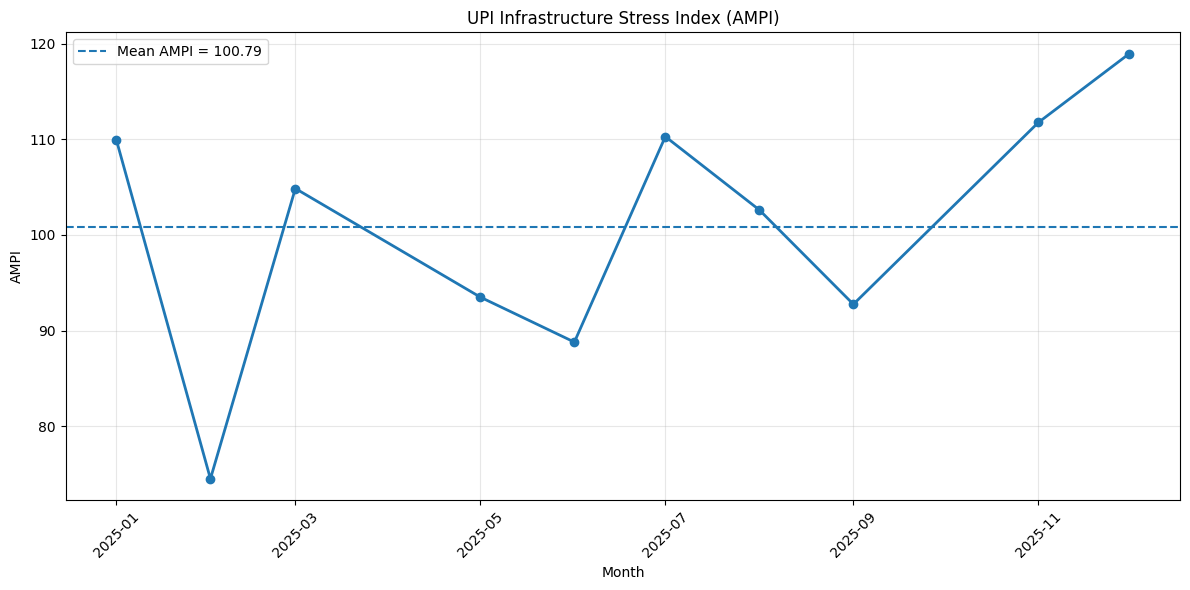

In [26]:
import matplotlib.pyplot as plt

plot_df = ampi_df.sort_values("month").copy()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_df["month"],
    plot_df["AMPI_final"],
    marker="o",
    linewidth=2
)

plt.axhline(
    plot_df["AMPI_final"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean AMPI = {plot_df['AMPI_final'].mean():.2f}"
)

plt.xlabel("Month")
plt.ylabel("AMPI")
plt.title("UPI Infrastructure Stress Index (AMPI)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

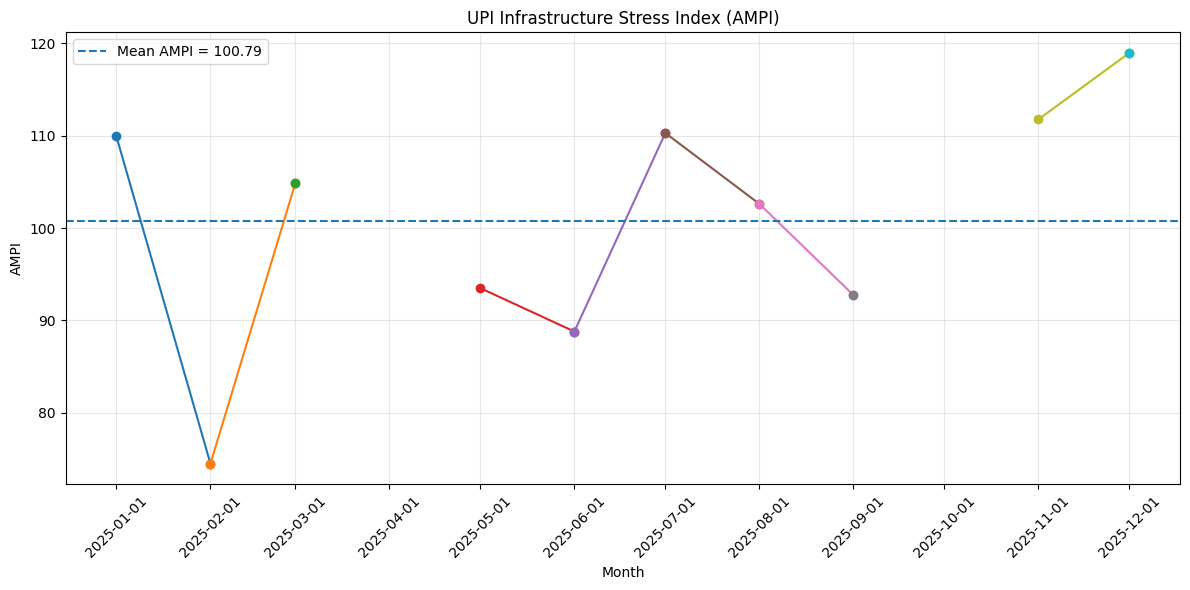

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = ampi_df.sort_values("month").copy()
plot_df["month"] = pd.to_datetime(plot_df["month"])

plt.figure(figsize=(12, 6))

# Plot each continuous period separately so missing months remain gaps
for i in range(len(plot_df) - 1):
    current = plot_df.iloc[i]
    next_row = plot_df.iloc[i + 1]

    month_gap = (
        (next_row["month"].year - current["month"].year) * 12
        + (next_row["month"].month - current["month"].month)
    )

    if month_gap == 1:
        plt.plot(
            [current["month"], next_row["month"]],
            [current["AMPI_final"], next_row["AMPI_final"]],
            marker="o"
        )
    else:
        plt.plot(
            current["month"],
            current["AMPI_final"],
            marker="o"
        )

# Plot final observation
plt.plot(
    plot_df.iloc[-1]["month"],
    plot_df.iloc[-1]["AMPI_final"],
    marker="o"
)

plt.axhline(
    plot_df["AMPI_final"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean AMPI = {plot_df['AMPI_final'].mean():.2f}"
)

plt.xlabel("Month")
plt.ylabel("AMPI")
plt.title("UPI Infrastructure Stress Index (AMPI)")
plt.xticks(
    pd.date_range(
        plot_df["month"].min(),
        plot_df["month"].max(),
        freq="MS"
    ),
    rotation=45
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
print("ISS DEFINITION SENSITIVITY ANALYSIS")
print("=" * 75)

# Normalize ISS maximum stress using the same AMPI goalpost method
ampi_df["iss_max_norm"] = ampi_normalize(ampi_df["iss_max_z"])

# Compute alternative AMPI using ISS maximum stress
ampi_max_result = compute_ampi_general(
    ampi_df,
    ["iss_max_norm", "sarima_norm", "rho_norm"]
)

ampi_df["AMPI_max"] = ampi_max_result["AMPI"]

# Compare primary and alternative AMPI
sensitivity = ampi_df[
    ["month", "AMPI_final", "AMPI_max"]
].copy()

sensitivity["Difference"] = (
    sensitivity["AMPI_max"] - sensitivity["AMPI_final"]
)

sensitivity["Absolute_difference"] = (
    sensitivity["Difference"].abs()
)

print("\nMonth-by-month comparison:")
print(
    sensitivity.round(4).to_string(index=False)
)

print("\nSummary:")
print(f"Primary AMPI mean:       {ampi_df['AMPI_final'].mean():.4f}")
print(f"ISS-max AMPI mean:       {ampi_df['AMPI_max'].mean():.4f}")
print(f"Mean absolute difference: {sensitivity['Absolute_difference'].mean():.4f}")
print(f"Maximum absolute difference: {sensitivity['Absolute_difference'].max():.4f}")

# Compare rankings
primary_rank = (
    ampi_df["AMPI_final"]
    .rank(method="min", ascending=False)
    .astype(int)
)

max_rank = (
    ampi_df["AMPI_max"]
    .rank(method="min", ascending=False)
    .astype(int)
)

print("\nRank comparison:")
rank_comparison = pd.DataFrame({
    "month": ampi_df["month"],
    "Primary_AMPI_rank": primary_rank,
    "ISS_max_AMPI_rank": max_rank
})

print(
    rank_comparison
    .sort_values("Primary_AMPI_rank")
    .to_string(index=False)
)

ISS DEFINITION SENSITIVITY ANALYSIS

Month-by-month comparison:
     month  AMPI_final  AMPI_max  Difference  Absolute_difference
2025-01-01    109.9092  109.9092      0.0000               0.0000
2025-02-01     74.5031   74.5100      0.0070               0.0070
2025-03-01    104.8515  114.4852      9.6337               9.6337
2025-05-01     93.4945  107.5901     14.0956              14.0956
2025-06-01     88.7943   93.2463      4.4519               4.4519
2025-07-01    110.2775  111.5778      1.3003               1.3003
2025-08-01    102.6094  113.7322     11.1228              11.1228
2025-09-01     92.7493   94.4905      1.7412               1.7412
2025-11-01    111.7536  111.7536      0.0000               0.0000
2025-12-01    118.9541  122.4053      3.4512               3.4512

Summary:
Primary AMPI mean:       100.7897
ISS-max AMPI mean:       105.3700
Mean absolute difference: 4.5804
Maximum absolute difference: 14.0956

Rank comparison:
     month  Primary_AMPI_rank  ISS_max_AMPI_

whether the three signals are actually capturing different dimensions

In [29]:
print("INTER-SIGNAL CORRELATION CHECK")
print("=" * 70)

raw_signals = ampi_df[
    [
        "sarima_resid_z",
        "iss_mean_z",
        "rho_peak_baseline"
    ]
].copy()

raw_signals.columns = [
    "SARIMA_demand",
    "ISS_supply",
    "Capacity_rho"
]

print("\nPearson correlation:")
print(
    raw_signals
    .corr(method="pearson")
    .round(4)
)

print("\nSpearman rank correlation:")
print(
    raw_signals
    .corr(method="spearman")
    .round(4)
)

print("\nInterpretation note:")
print("These correlations are descriptive only.")
print("AMPI does not require the indicators to be uncorrelated.")

INTER-SIGNAL CORRELATION CHECK

Pearson correlation:
               SARIMA_demand  ISS_supply  Capacity_rho
SARIMA_demand         1.0000      0.4038        0.2362
ISS_supply            0.4038      1.0000       -0.2317
Capacity_rho          0.2362     -0.2317        1.0000

Spearman rank correlation:
               SARIMA_demand  ISS_supply  Capacity_rho
SARIMA_demand         1.0000      0.2970        0.2727
ISS_supply            0.2970      1.0000       -0.2121
Capacity_rho          0.2727     -0.2121        1.0000

Interpretation note:
These correlations are descriptive only.
AMPI does not require the indicators to be uncorrelated.


statistical validation of the AMPI trend

In [30]:
from scipy.stats import spearmanr

trend_df = ampi_df.sort_values("month").copy()

# Convert dates into an ordered time index
time_index = range(1, len(trend_df) + 1)

rho_trend, p_trend = spearmanr(
    time_index,
    trend_df["AMPI_final"]
)

print("AMPI TEMPORAL TREND CHECK")
print("=" * 60)

print(f"Spearman time-AMPI correlation: {rho_trend:.4f}")
print(f"p-value: {p_trend:.4f}")

print("\nNumber of observations:")
print(len(trend_df))

if p_trend < 0.05:
    print("\nResult: statistically significant monotonic trend at 5%.")
else:
    print("\nResult: no statistically significant monotonic trend at 5%.")

print("\nImportant:")
print("This is a descriptive trend test with only 10 complete observations.")
print("It does not establish causality.")

AMPI TEMPORAL TREND CHECK
Spearman time-AMPI correlation: 0.4667
p-value: 0.1739

Number of observations:
10

Result: no statistically significant monotonic trend at 5%.

Important:
This is a descriptive trend test with only 10 complete observations.
It does not establish causality.


validate the AMPI against the known disruption period

In [31]:
print("DISRUPTION-PERIOD AMPI CHECK")
print("=" * 70)

disruption_months = ["2025-03", "2025-05", "2025-06"]

disruption_check = ampi_df[
    ampi_df["month"].dt.strftime("%Y-%m").isin(disruption_months)
][
    [
        "month",
        "iss_mean_z",
        "sarima_resid_z",
        "rho_peak_baseline",
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "Mean",
        "Penalty",
        "AMPI_final"
    ]
].copy()

print("\nAMPI values around the March-April 2025 disruption:")
print(
    disruption_check.round(4).to_string(index=False)
)

print("\nAMPI change:")
for i in range(len(disruption_check) - 1):
    current = disruption_check.iloc[i]
    next_row = disruption_check.iloc[i + 1]

    change = next_row["AMPI_final"] - current["AMPI_final"]

    print(
        f"{current['month'].strftime('%Y-%m')} → "
        f"{next_row['month'].strftime('%Y-%m')}: "
        f"{change:+.4f}"
    )

print("\nImportant limitation:")
print("April 2025 is absent because ISS data are unavailable.")
print("Therefore, April cannot be assigned an AMPI value without imputation.")

DISRUPTION-PERIOD AMPI CHECK

AMPI values around the March-April 2025 disruption:
     month  iss_mean_z  sarima_resid_z  rho_peak_baseline  iss_mean_norm  sarima_norm  rho_norm     Mean  Penalty  AMPI_final
2025-03-01     -0.0715          0.9546             0.7797        84.6759     130.0000   86.8864 100.5208   4.3307    104.8515
2025-05-01     -0.0982         -0.2456             0.7957        83.5937     103.0772   91.7493  92.8067   0.6877     93.4945
2025-06-01     -0.3946         -0.6288             0.8098        71.5881      94.4805   96.0270  87.3652   1.4291     88.7943

AMPI change:
2025-03 → 2025-05: -11.3570
2025-05 → 2025-06: -4.7001

Important limitation:
April 2025 is absent because ISS data are unavailable.
Therefore, April cannot be assigned an AMPI value without imputation.


In [33]:
print("CAPACITY SCENARIO SENSITIVITY ANALYSIS")
print("=" * 75)

# Start from the complete AMPI dataframe so the normalized
# ISS and SARIMA indicators are retained
capacity_sensitivity = ampi_df[
    [
        "month",
        "iss_mean_norm",
        "sarima_norm",
        "AMPI_final"
    ]
].copy()

capacity_sensitivity["month"] = pd.to_datetime(
    capacity_sensitivity["month"]
)

# Add the alternative M/M/1 capacity scenarios
rho_scenarios = mm1[
    [
        "month",
        "rho_floor",
        "rho_sens_low",
        "rho_sens_high"
    ]
].copy()

rho_scenarios["month"] = pd.to_datetime(
    rho_scenarios["month"]
)

capacity_sensitivity = capacity_sensitivity.merge(
    rho_scenarios,
    on="month",
    how="inner"
)

scenario_results = []

for scenario in [
    "rho_floor",
    "rho_sens_low",
    "rho_sens_high"
]:

    # Normalize the alternative capacity signal
    capacity_sensitivity[f"{scenario}_norm"] = ampi_normalize(
        capacity_sensitivity[scenario]
    )

    # Calculate alternative AMPI
    result = compute_ampi_general(
        capacity_sensitivity,
        [
            "iss_mean_norm",
            "sarima_norm",
            f"{scenario}_norm"
        ]
    )

    capacity_sensitivity[f"AMPI_{scenario}"] = result["AMPI"]

    scenario_results.append({
        "Scenario": scenario,
        "Mean_AMPI": result["AMPI"].mean(),
        "Min_AMPI": result["AMPI"].min(),
        "Max_AMPI": result["AMPI"].max()
    })

scenario_summary = pd.DataFrame(scenario_results)

print("\nScenario summary:")
print(
    scenario_summary.round(4).to_string(index=False)
)

print("\nPrimary vs alternative AMPI:")
comparison = capacity_sensitivity[
    [
        "month",
        "AMPI_final",
        "AMPI_rho_floor",
        "AMPI_rho_sens_low",
        "AMPI_rho_sens_high"
    ]
].copy()

print(
    comparison.round(4).to_string(index=False)
)

print("\nRank of December 2025 under each scenario:")

for column in [
    "AMPI_final",
    "AMPI_rho_floor",
    "AMPI_rho_sens_low",
    "AMPI_rho_sens_high"
]:
    rank = (
        capacity_sensitivity[column]
        .rank(method="min", ascending=False)
    )

    dec_rank = rank[
        capacity_sensitivity["month"] ==
        pd.Timestamp("2025-12-01")
    ].iloc[0]

    print(f"{column}: Rank {int(dec_rank)}")

CAPACITY SCENARIO SENSITIVITY ANALYSIS

Scenario summary:
     Scenario  Mean_AMPI  Min_AMPI  Max_AMPI
    rho_floor   100.7897   74.5031  118.9541
 rho_sens_low   100.7897   74.5031  118.9541
rho_sens_high   100.7897   74.5031  118.9541

Primary vs alternative AMPI:
     month  AMPI_final  AMPI_rho_floor  AMPI_rho_sens_low  AMPI_rho_sens_high
2025-01-01    109.9092        109.9092           109.9092            109.9092
2025-02-01     74.5031         74.5031            74.5031             74.5031
2025-03-01    104.8515        104.8515           104.8515            104.8515
2025-05-01     93.4945         93.4945            93.4945             93.4945
2025-06-01     88.7943         88.7943            88.7943             88.7943
2025-07-01    110.2775        110.2775           110.2775            110.2775
2025-08-01    102.6094        102.6094           102.6094            102.6094
2025-09-01     92.7493         92.7493            92.7493             92.7493
2025-11-01    111.7536        

inspect the raw capacity scenarios

In [34]:
print("RAW CAPACITY SCENARIO CHECK")
print("=" * 75)

capacity_check = mm1[
    [
        "month",
        "rho_floor",
        "rho_sens_low",
        "rho_sens_high",
        "rho_peak_baseline"
    ]
].copy()

capacity_check["month"] = pd.to_datetime(
    capacity_check["month"]
)

# Keep only months used in the final AMPI
capacity_check = capacity_check[
    capacity_check["month"].isin(ampi_df["month"])
].copy()

print("\nRaw capacity values for AMPI months:")
print(
    capacity_check.round(6).to_string(index=False)
)

print("\nRanges:")
for column in [
    "rho_floor",
    "rho_sens_low",
    "rho_sens_high",
    "rho_peak_baseline"
]:
    print(
        f"{column}: "
        f"{capacity_check[column].min():.6f} "
        f"to "
        f"{capacity_check[column].max():.6f}"
    )

print("\nCorrelation with primary rho:")
print(
    capacity_check[
        [
            "rho_floor",
            "rho_sens_low",
            "rho_sens_high",
            "rho_peak_baseline"
        ]
    ].corr().round(6)
)

RAW CAPACITY SCENARIO CHECK

Raw capacity values for AMPI months:
     month  rho_floor  rho_sens_low  rho_sens_high  rho_peak_baseline
2025-01-01   0.919206      0.766005       0.510670           0.724058
2025-02-01   0.964412      0.803677       0.535785           0.759666
2025-03-01   0.989813      0.824844       0.549896           0.779674
2025-05-01   1.010146      0.841788       0.561192           0.795691
2025-06-01   1.028032      0.856693       0.571129           0.809780
2025-07-01   1.052898      0.877415       0.584944           0.829367
2025-08-01   1.082123      0.901769       0.601179           0.852387
2025-09-01   1.097243      0.914369       0.609579           0.864297
2025-11-01   1.143827      0.953189       0.635460           0.900991
2025-12-01   1.170082      0.975069       0.650046           0.921673

Ranges:
rho_floor: 0.919206 to 1.170082
rho_sens_low: 0.766005 to 0.975069
rho_sens_high: 0.510670 to 0.650046
rho_peak_baseline: 0.724058 to 0.921673

Correlation

“Sensitivity analysis across the alternative M/M/1 service-rate scenarios produced identical normalized capacity rankings because the scenario-specific utilization series were perfectly linearly correlated. Consequently, the resulting AMPI values were unchanged under min–max goalpost normalization.”

verify the exact linear relationship

In [35]:
print("CAPACITY SCENARIO LINEAR-TRANSFORMATION CHECK")
print("=" * 75)

primary = capacity_check["rho_peak_baseline"]

for scenario in [
    "rho_floor",
    "rho_sens_low",
    "rho_sens_high"
]:

    alternative = capacity_check[scenario]

    # Fit alternative = intercept + slope × primary
    slope, intercept = __import__("numpy").polyfit(
        primary,
        alternative,
        1
    )

    predicted = intercept + slope * primary

    max_error = (
        alternative - predicted
    ).abs().max()

    r2 = (
        __import__("numpy").corrcoef(
            primary,
            alternative
        )[0, 1] ** 2
    )

    print(f"\n{scenario}")
    print(f"Slope:       {slope:.6f}")
    print(f"Intercept:   {intercept:.6f}")
    print(f"R²:          {r2:.6f}")
    print(f"Max error:   {max_error:.10f}")

CAPACITY SCENARIO LINEAR-TRANSFORMATION CHECK

rho_floor
Slope:       1.269521
Intercept:   0.000000
R²:          1.000000
Max error:   0.0000000000

rho_sens_low
Slope:       1.057934
Intercept:   0.000000
R²:          1.000000
Max error:   0.0000000000

rho_sens_high
Slope:       0.705289
Intercept:   0.000000
R²:          1.000000
Max error:   0.0000000000


In [36]:
final_ampi_dataset = ampi_df[
    [
        "month",
        "iss_mean_z",
        "iss_max_z",
        "sarima_resid_z",
        "rho_peak_baseline",
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "Mean",
        "Population_SD",
        "CV",
        "Penalty",
        "AMPI_final"
    ]
].copy()

final_ampi_dataset = final_ampi_dataset.sort_values(
    "month"
).reset_index(drop=True)

print("FINAL AMPI DATASET")
print("=" * 80)

print(f"Rows: {len(final_ampi_dataset)}")
print(f"Columns: {len(final_ampi_dataset.columns)}")

print("\nColumn list:")
print(final_ampi_dataset.columns.tolist())

print("\nFinal dataset:")
print(
    final_ampi_dataset.round(4).to_string(index=False)
)

print("\nMissing values:")
print(
    final_ampi_dataset.isna().sum()
)

FINAL AMPI DATASET
Rows: 10
Columns: 13

Column list:
['month', 'iss_mean_z', 'iss_max_z', 'sarima_resid_z', 'rho_peak_baseline', 'iss_mean_norm', 'sarima_norm', 'rho_norm', 'Mean', 'Population_SD', 'CV', 'Penalty', 'AMPI_final']

Final dataset:
     month  iss_mean_z  iss_max_z  sarima_resid_z  rho_peak_baseline  iss_mean_norm  sarima_norm  rho_norm     Mean  Population_SD     CV  Penalty  AMPI_final
2025-01-01      1.0474     2.1302          0.1316             0.7241       130.0000     111.5396   70.0000 103.8465        25.0917 0.2416   6.0627    109.9092
2025-02-01     -0.3895     0.2513         -1.7201             0.7597        71.7928      70.0000   80.8115  74.2014         4.7310 0.0638   0.3016     74.5031
2025-03-01     -0.0715     1.7337          0.9546             0.7797        84.6759     130.0000   86.8864 100.5208        20.8645 0.2076   4.3307    104.8515
2025-05-01     -0.0982     1.9096         -0.2456             0.7957        83.5937     103.0772   91.7493  92.8067   

In [37]:
# Save the verified final AMPI dataset
output_path = "/content/AMPI_final_verified.csv"

final_ampi_dataset.to_csv(
    output_path,
    index=False
)

print("AMPI dataset saved successfully.")
print(f"File: {output_path}")

# Verify that the saved file can be read back correctly
verification = pd.read_csv(output_path)

print("\nSaved file verification:")
print(f"Rows: {len(verification)}")
print(f"Columns: {len(verification.columns)}")
print(f"Missing values: {verification.isna().sum().sum()}")

print("\nAMPI range:")
print(
    f"{verification['AMPI_final'].min():.4f} "
    f"to "
    f"{verification['AMPI_final'].max():.4f}"
)

AMPI dataset saved successfully.
File: /content/AMPI_final_verified.csv

Saved file verification:
Rows: 10
Columns: 13
Missing values: 0

AMPI range:
74.5031 to 118.9541


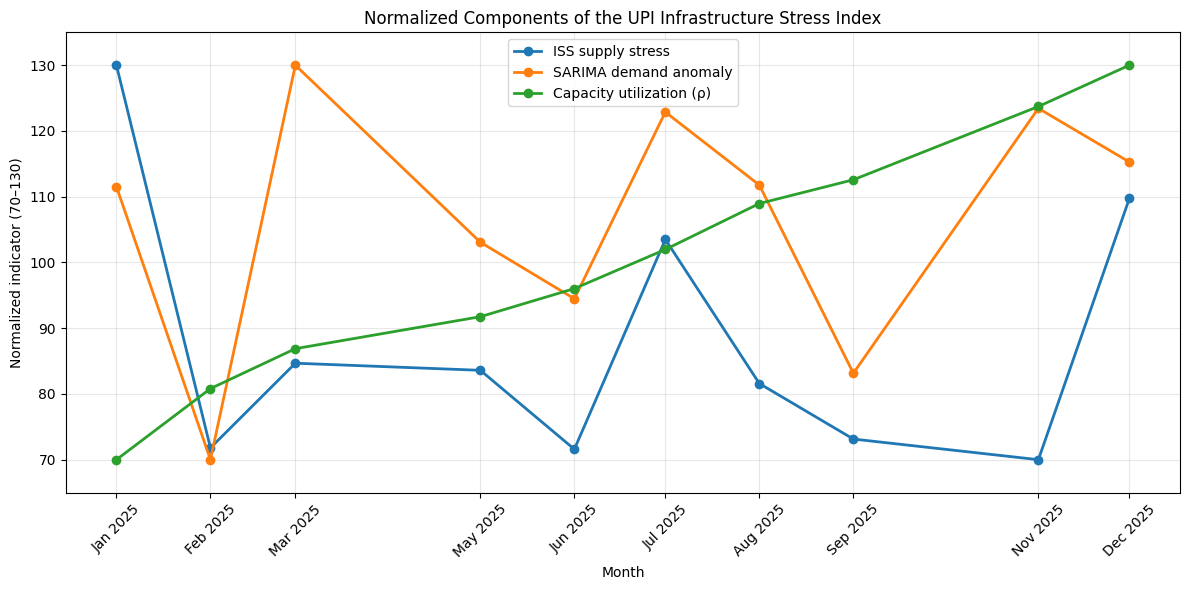

In [38]:
import matplotlib.pyplot as plt

component_plot = ampi_df.sort_values("month").copy()

plt.figure(figsize=(12, 6))

plt.plot(
    component_plot["month"],
    component_plot["iss_mean_norm"],
    marker="o",
    linewidth=2,
    label="ISS supply stress"
)

plt.plot(
    component_plot["month"],
    component_plot["sarima_norm"],
    marker="o",
    linewidth=2,
    label="SARIMA demand anomaly"
)

plt.plot(
    component_plot["month"],
    component_plot["rho_norm"],
    marker="o",
    linewidth=2,
    label="Capacity utilization (ρ)"
)

plt.xlabel("Month")
plt.ylabel("Normalized indicator (70–130)")
plt.title("Normalized Components of the UPI Infrastructure Stress Index")
plt.xticks(
    component_plot["month"],
    component_plot["month"].dt.strftime("%b %Y"),
    rotation=45
)

plt.ylim(65, 135)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

research-safe component plot with gaps

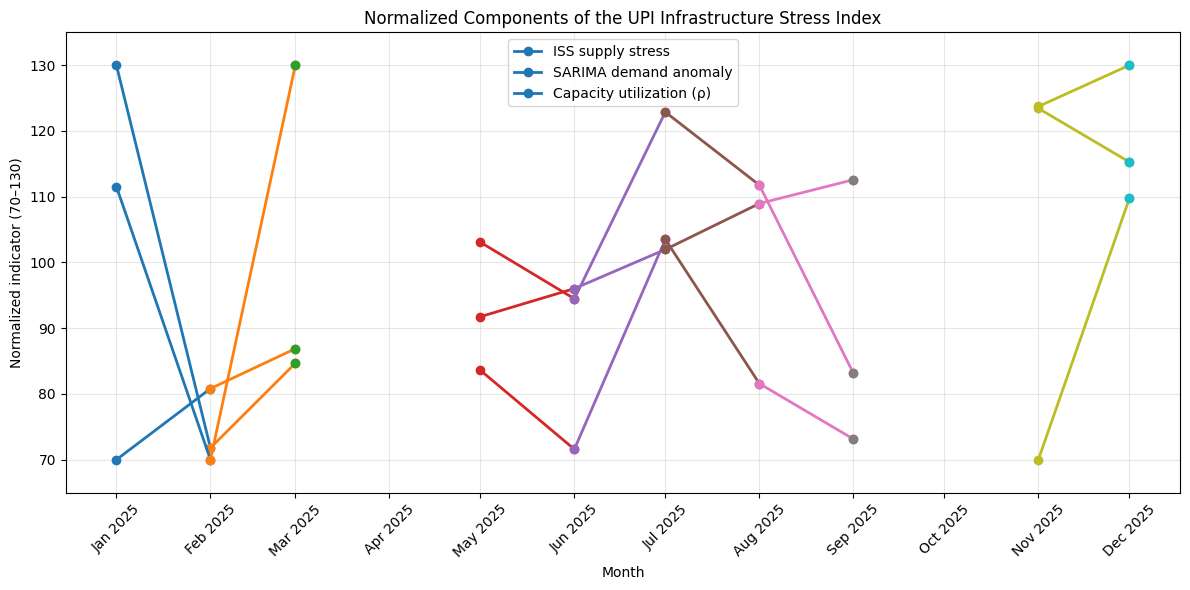

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

component_plot = ampi_df.sort_values("month").copy()
component_plot["month"] = pd.to_datetime(component_plot["month"])

plt.figure(figsize=(12, 6))

signals = [
    ("iss_mean_norm", "ISS supply stress"),
    ("sarima_norm", "SARIMA demand anomaly"),
    ("rho_norm", "Capacity utilization (ρ)")
]

for column, label in signals:

    for i in range(len(component_plot) - 1):

        current = component_plot.iloc[i]
        next_row = component_plot.iloc[i + 1]

        month_gap = (
            (next_row["month"].year - current["month"].year) * 12
            + (next_row["month"].month - current["month"].month)
        )

        if month_gap == 1:
            plt.plot(
                [current["month"], next_row["month"]],
                [current[column], next_row[column]],
                marker="o",
                linewidth=2,
                label=label if i == 0 else None
            )
        else:
            plt.plot(
                current["month"],
                current[column],
                marker="o",
                linewidth=2
            )

    # Final observation
    plt.plot(
        component_plot.iloc[-1]["month"],
        component_plot.iloc[-1][column],
        marker="o",
        linewidth=2
    )

plt.xlabel("Month")
plt.ylabel("Normalized indicator (70–130)")
plt.title("Normalized Components of the UPI Infrastructure Stress Index")

plt.xticks(
    pd.date_range(
        component_plot["month"].min(),
        component_plot["month"].max(),
        freq="MS"
    ),
    [
        d.strftime("%b %Y")
        for d in pd.date_range(
            component_plot["month"].min(),
            component_plot["month"].max(),
            freq="MS"
        )
    ],
    rotation=45
)

plt.ylim(65, 135)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

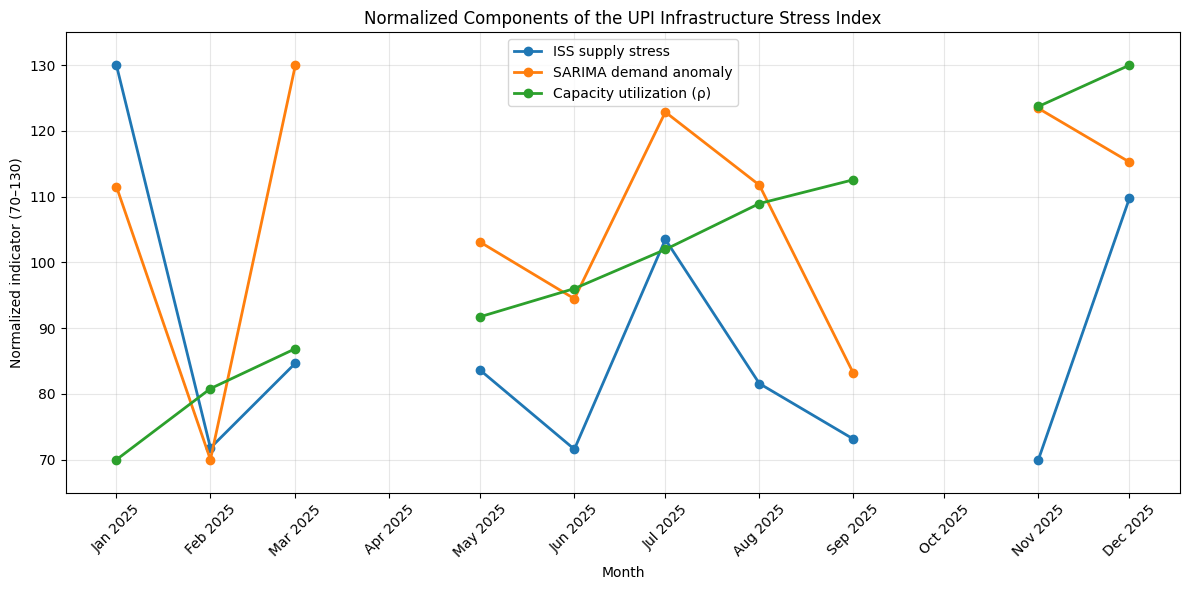

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

component_plot = ampi_df.sort_values("month").copy()
component_plot["month"] = pd.to_datetime(component_plot["month"])

# Create complete monthly timeline
all_months = pd.date_range(
    component_plot["month"].min(),
    component_plot["month"].max(),
    freq="MS"
)

# Reindex so missing April and October remain as NaN
component_plot = (
    component_plot
    .set_index("month")
    .reindex(all_months)
    .rename_axis("month")
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    component_plot["month"],
    component_plot["iss_mean_norm"],
    marker="o",
    linewidth=2,
    label="ISS supply stress"
)

plt.plot(
    component_plot["month"],
    component_plot["sarima_norm"],
    marker="o",
    linewidth=2,
    label="SARIMA demand anomaly"
)

plt.plot(
    component_plot["month"],
    component_plot["rho_norm"],
    marker="o",
    linewidth=2,
    label="Capacity utilization (ρ)"
)

plt.xlabel("Month")
plt.ylabel("Normalized indicator (70–130)")
plt.title("Normalized Components of the UPI Infrastructure Stress Index")

plt.xticks(
    all_months,
    [d.strftime("%b %Y") for d in all_months],
    rotation=45
)

plt.ylim(65, 135)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

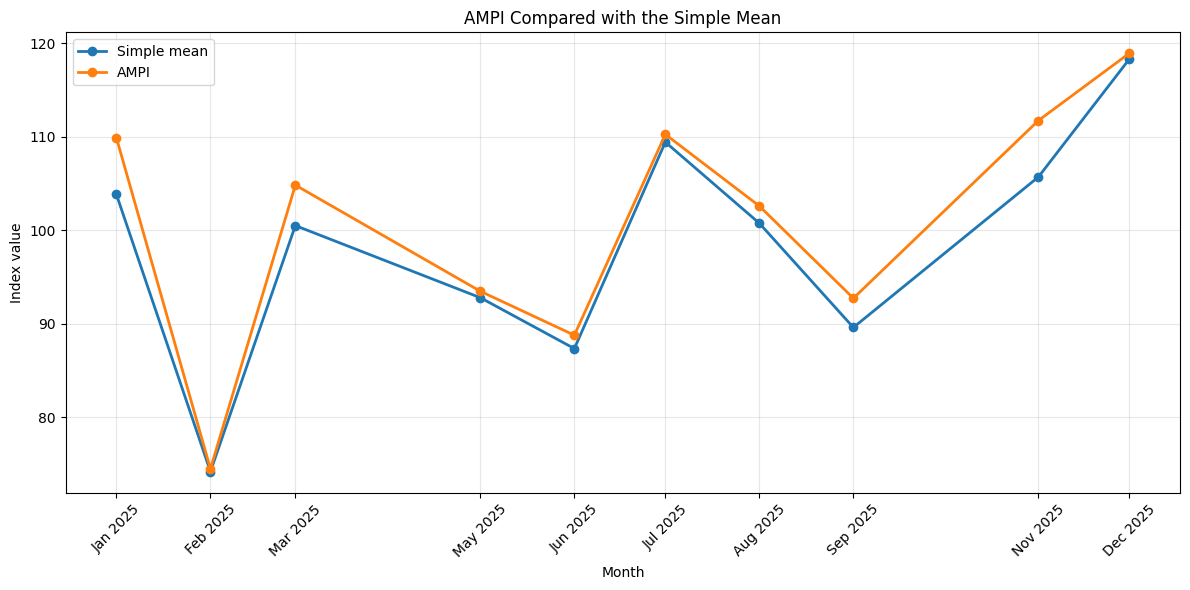

In [41]:
import matplotlib.pyplot as plt

comparison_plot = ampi_df.sort_values("month").copy()

plt.figure(figsize=(12, 6))

plt.plot(
    comparison_plot["month"],
    comparison_plot["Mean"],
    marker="o",
    linewidth=2,
    label="Simple mean"
)

plt.plot(
    comparison_plot["month"],
    comparison_plot["AMPI_final"],
    marker="o",
    linewidth=2,
    label="AMPI"
)

plt.xlabel("Month")
plt.ylabel("Index value")
plt.title("AMPI Compared with the Simple Mean")

plt.xticks(
    comparison_plot["month"],
    comparison_plot["month"].dt.strftime("%b %Y"),
    rotation=45
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

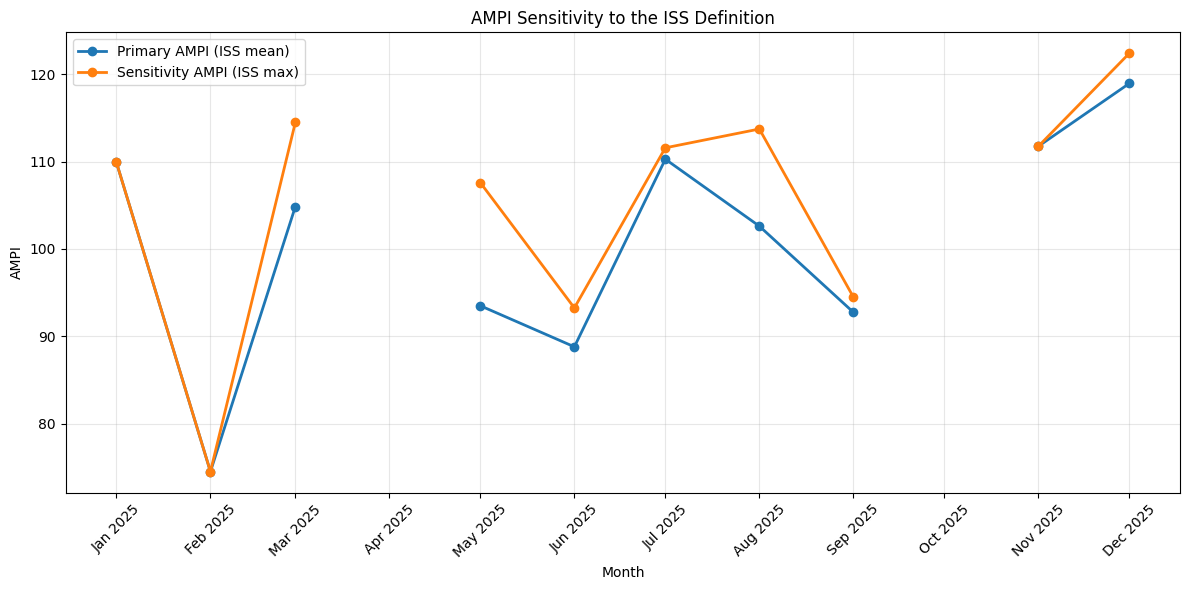

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sensitivity_plot = ampi_df.sort_values("month").copy()
sensitivity_plot["month"] = pd.to_datetime(sensitivity_plot["month"])

# Complete monthly timeline to preserve missing April and October
all_months = pd.date_range(
    sensitivity_plot["month"].min(),
    sensitivity_plot["month"].max(),
    freq="MS"
)

sensitivity_plot = (
    sensitivity_plot
    .set_index("month")
    .reindex(all_months)
    .rename_axis("month")
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    sensitivity_plot["month"],
    sensitivity_plot["AMPI_final"],
    marker="o",
    linewidth=2,
    label="Primary AMPI (ISS mean)"
)

plt.plot(
    sensitivity_plot["month"],
    sensitivity_plot["AMPI_max"],
    marker="o",
    linewidth=2,
    label="Sensitivity AMPI (ISS max)"
)

plt.xlabel("Month")
plt.ylabel("AMPI")
plt.title("AMPI Sensitivity to the ISS Definition")

plt.xticks(
    all_months,
    [d.strftime("%b %Y") for d in all_months],
    rotation=45
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
print("FINAL AMPI END-TO-END VALIDATION")
print("=" * 75)

# ---------------------------------------------------------
# 1. Observation and date checks
# ---------------------------------------------------------
print("\n1. OBSERVATION CHECK")

print(f"Number of AMPI observations: {len(final_ampi_dataset)}")
print(f"Duplicate months: {final_ampi_dataset['month'].duplicated().sum()}")

print(
    f"Date range: "
    f"{final_ampi_dataset['month'].min()} "
    f"to "
    f"{final_ampi_dataset['month'].max()}"
)

# ---------------------------------------------------------
# 2. Missing-value check
# ---------------------------------------------------------
print("\n2. MISSING-VALUE CHECK")

total_missing = final_ampi_dataset.isna().sum().sum()

print(f"Total missing values: {total_missing}")

# ---------------------------------------------------------
# 3. Normalization check
# ---------------------------------------------------------
print("\n3. NORMALIZATION CHECK")

for column in [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm"
]:
    print(
        f"{column}: "
        f"min={final_ampi_dataset[column].min():.4f}, "
        f"max={final_ampi_dataset[column].max():.4f}"
    )

# ---------------------------------------------------------
# 4. AMPI formula check
# ---------------------------------------------------------
print("\n4. AMPI FORMULA CHECK")

formula_error = (
    final_ampi_dataset["AMPI_final"]
    - (
        final_ampi_dataset["Mean"]
        + final_ampi_dataset["Penalty"]
    )
).abs().max()

print(
    f"Maximum |AMPI - (Mean + Penalty)|: "
    f"{formula_error:.10f}"
)

# ---------------------------------------------------------
# 5. Primary signal check
# ---------------------------------------------------------
print("\n5. PRIMARY SIGNAL CHECK")

print("Primary supply signal: iss_mean_z")
print("Primary demand signal: sarima_resid_z")
print("Primary capacity signal: rho_peak_baseline")

print(
    "\nPrimary AMPI columns present:"
)

required_columns = [
    "iss_mean_z",
    "sarima_resid_z",
    "rho_peak_baseline",
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm",
    "Mean",
    "Population_SD",
    "CV",
    "Penalty",
    "AMPI_final"
]

for column in required_columns:
    print(
        f"{column}: "
        f"{column in final_ampi_dataset.columns}"
    )

# ---------------------------------------------------------
# 6. Final AMPI statistics
# ---------------------------------------------------------
print("\n6. FINAL AMPI STATISTICS")

print(
    f"Minimum: {final_ampi_dataset['AMPI_final'].min():.4f}"
)

print(
    f"Maximum: {final_ampi_dataset['AMPI_final'].max():.4f}"
)

print(
    f"Mean:    {final_ampi_dataset['AMPI_final'].mean():.4f}"
)

print(
    f"Median:  {final_ampi_dataset['AMPI_final'].median():.4f}"
)

# ---------------------------------------------------------
# 7. Sensitivity check
# ---------------------------------------------------------
print("\n7. SENSITIVITY CHECK")

print(
    f"ISS-max AMPI mean: "
    f"{ampi_df['AMPI_max'].mean():.4f}"
)

print(
    f"Primary AMPI mean: "
    f"{ampi_df['AMPI_final'].mean():.4f}"
)

print(
    f"Mean absolute ISS-definition difference: "
    f"{sensitivity['Absolute_difference'].mean():.4f}"
)

# ---------------------------------------------------------
# 8. Overall validation status
# ---------------------------------------------------------
print("\n8. OVERALL VALIDATION STATUS")

checks_passed = [
    len(final_ampi_dataset) == 10,
    final_ampi_dataset["month"].duplicated().sum() == 0,
    total_missing == 0,
    all(
        abs(final_ampi_dataset[column].min() - 70) < 1e-10
        and abs(final_ampi_dataset[column].max() - 130) < 1e-10
        for column in [
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm"
        ]
    ),
    formula_error < 1e-10,
    all(
        column in final_ampi_dataset.columns
        for column in required_columns
    )
]

print(
    f"Checks passed: {sum(checks_passed)} / {len(checks_passed)}"
)

if all(checks_passed):
    print("\nSTATUS: ALL PRIMARY AMPI VALIDATION CHECKS PASSED.")
else:
    print("\nSTATUS: REVIEW REQUIRED.")

FINAL AMPI END-TO-END VALIDATION

1. OBSERVATION CHECK
Number of AMPI observations: 10
Duplicate months: 0
Date range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00

2. MISSING-VALUE CHECK
Total missing values: 0

3. NORMALIZATION CHECK
iss_mean_norm: min=70.0000, max=130.0000
sarima_norm: min=70.0000, max=130.0000
rho_norm: min=70.0000, max=130.0000

4. AMPI FORMULA CHECK
Maximum |AMPI - (Mean + Penalty)|: 0.0000000000

5. PRIMARY SIGNAL CHECK
Primary supply signal: iss_mean_z
Primary demand signal: sarima_resid_z
Primary capacity signal: rho_peak_baseline

Primary AMPI columns present:
iss_mean_z: True
sarima_resid_z: True
rho_peak_baseline: True
iss_mean_norm: True
sarima_norm: True
rho_norm: True
Mean: True
Population_SD: True
CV: True
Penalty: True
AMPI_final: True

6. FINAL AMPI STATISTICS
Minimum: 74.5031
Maximum: 118.9541
Mean:    100.7897
Median:  103.7305

7. SENSITIVITY CHECK
ISS-max AMPI mean: 105.3700
Primary AMPI mean: 100.7897
Mean absolute ISS-definition difference: 4.5804

In [46]:
# ---------------------------------------------------------
# Export AMPI sensitivity analysis results
# ---------------------------------------------------------

# 1. ISS definition sensitivity
iss_sensitivity_output = ampi_df[
    [
        "month",
        "iss_mean_z",
        "iss_max_z",
        "AMPI_final",
        "AMPI_max"
    ]
].copy()

iss_sensitivity_output["AMPI_difference"] = (
    iss_sensitivity_output["AMPI_max"]
    - iss_sensitivity_output["AMPI_final"]
)

iss_sensitivity_path = "/content/AMPI_ISS_sensitivity.csv"

iss_sensitivity_output.to_csv(
    iss_sensitivity_path,
    index=False
)


# 2. Capacity scenario sensitivity
capacity_sensitivity_output = capacity_sensitivity[
    [
        "month",
        "rho_floor",
        "rho_sens_low",
        "rho_sens_high",
        "AMPI_final",
        "AMPI_rho_floor",
        "AMPI_rho_sens_low",
        "AMPI_rho_sens_high"
    ]
].copy()

# Add the primary rho signal from the original M/M/1 dataset
primary_rho = mm1[
    [
        "month",
        "rho_peak_baseline"
    ]
].copy()

primary_rho["month"] = pd.to_datetime(primary_rho["month"])

capacity_sensitivity_output = capacity_sensitivity_output.merge(
    primary_rho,
    on="month",
    how="left"
)

# Put primary rho next to the other rho scenarios
capacity_sensitivity_output = capacity_sensitivity_output[
    [
        "month",
        "rho_floor",
        "rho_sens_low",
        "rho_sens_high",
        "rho_peak_baseline",
        "AMPI_final",
        "AMPI_rho_floor",
        "AMPI_rho_sens_low",
        "AMPI_rho_sens_high"
    ]
]

capacity_sensitivity_path = "/content/AMPI_capacity_sensitivity.csv"

capacity_sensitivity_output.to_csv(
    capacity_sensitivity_path,
    index=False
)


# ---------------------------------------------------------
# Verify saved files
# ---------------------------------------------------------

print("SENSITIVITY FILES EXPORTED")
print("=" * 70)

print("\nISS sensitivity:")
print(f"File: {iss_sensitivity_path}")
print(f"Rows: {len(iss_sensitivity_output)}")
print(f"Columns: {len(iss_sensitivity_output.columns)}")
print(
    f"Missing values: "
    f"{iss_sensitivity_output.isna().sum().sum()}"
)

print("\nCapacity sensitivity:")
print(f"File: {capacity_sensitivity_path}")
print(f"Rows: {len(capacity_sensitivity_output)}")
print(f"Columns: {len(capacity_sensitivity_output.columns)}")
print(
    f"Missing values: "
    f"{capacity_sensitivity_output.isna().sum().sum()}"
)

SENSITIVITY FILES EXPORTED

ISS sensitivity:
File: /content/AMPI_ISS_sensitivity.csv
Rows: 10
Columns: 6
Missing values: 0

Capacity sensitivity:
File: /content/AMPI_capacity_sensitivity.csv
Rows: 10
Columns: 9
Missing values: 0


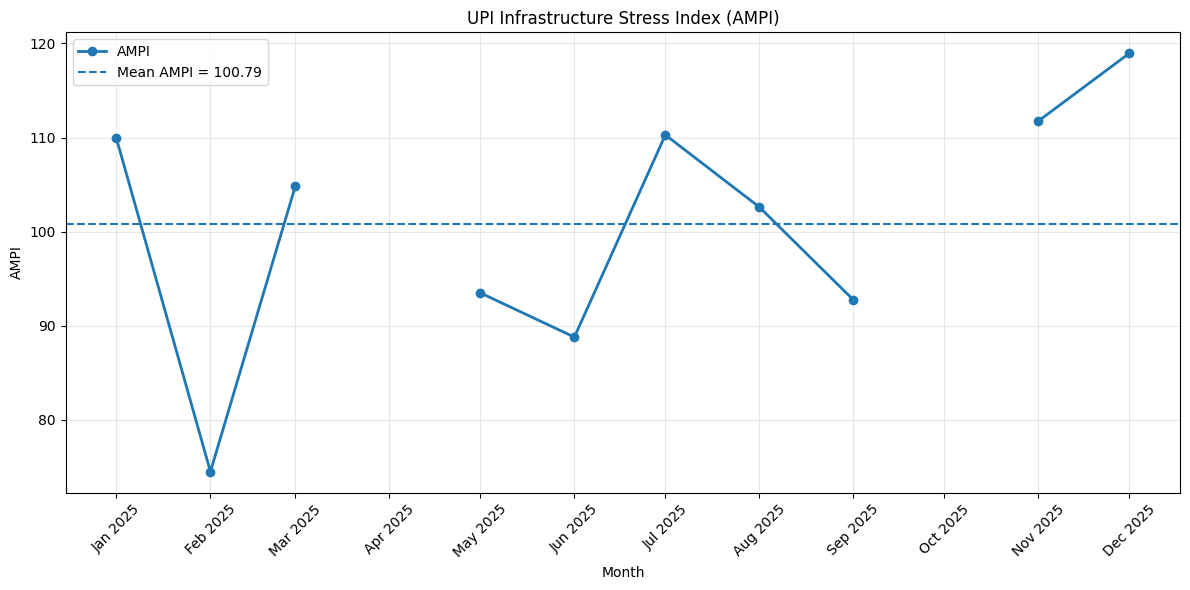


Figure saved successfully.
File: /content/figures/AMPI_trend.png
Resolution: 300 DPI


In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Create figures folder
figures_path = "/content/figures"
os.makedirs(figures_path, exist_ok=True)

# Prepare monthly timeline
trend_plot = final_ampi_dataset.copy()
trend_plot["month"] = pd.to_datetime(trend_plot["month"])

all_months = pd.date_range(
    trend_plot["month"].min(),
    trend_plot["month"].max(),
    freq="MS"
)

trend_plot = (
    trend_plot
    .set_index("month")
    .reindex(all_months)
    .rename_axis("month")
    .reset_index()
)

# Create figure
plt.figure(figsize=(12, 6))

plt.plot(
    trend_plot["month"],
    trend_plot["AMPI_final"],
    marker="o",
    linewidth=2,
    label="AMPI"
)

plt.axhline(
    final_ampi_dataset["AMPI_final"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Mean AMPI = "
        f"{final_ampi_dataset['AMPI_final'].mean():.2f}"
    )
)

plt.xlabel("Month")
plt.ylabel("AMPI")
plt.title("UPI Infrastructure Stress Index (AMPI)")

plt.xticks(
    all_months,
    [d.strftime("%b %Y") for d in all_months],
    rotation=45
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Save high-resolution figure
figure1_path = os.path.join(
    figures_path,
    "AMPI_trend.png"
)

plt.savefig(
    figure1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully.")
print(f"File: {figure1_path}")
print(f"Resolution: 300 DPI")

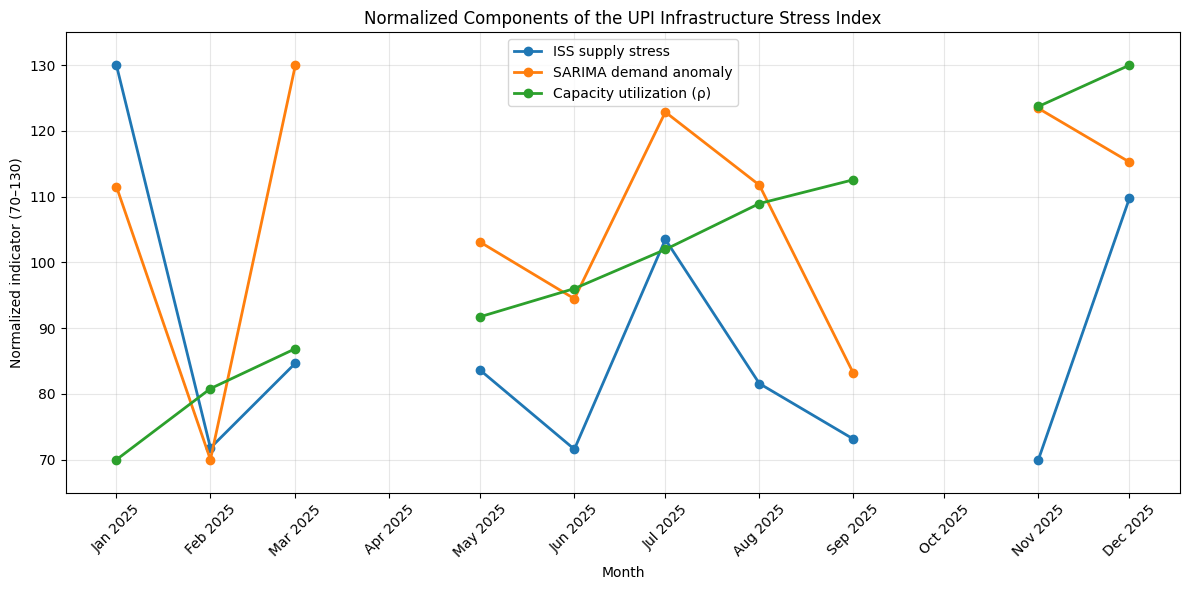


Figure saved successfully.
File: /content/figures/AMPI_components.png
Resolution: 300 DPI


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Prepare data
component_plot = final_ampi_dataset.copy()
component_plot["month"] = pd.to_datetime(component_plot["month"])

all_months = pd.date_range(
    component_plot["month"].min(),
    component_plot["month"].max(),
    freq="MS"
)

component_plot = (
    component_plot
    .set_index("month")
    .reindex(all_months)
    .rename_axis("month")
    .reset_index()
)

# Create figure
plt.figure(figsize=(12, 6))

plt.plot(
    component_plot["month"],
    component_plot["iss_mean_norm"],
    marker="o",
    linewidth=2,
    label="ISS supply stress"
)

plt.plot(
    component_plot["month"],
    component_plot["sarima_norm"],
    marker="o",
    linewidth=2,
    label="SARIMA demand anomaly"
)

plt.plot(
    component_plot["month"],
    component_plot["rho_norm"],
    marker="o",
    linewidth=2,
    label="Capacity utilization (ρ)"
)

plt.xlabel("Month")
plt.ylabel("Normalized indicator (70–130)")
plt.title(
    "Normalized Components of the UPI Infrastructure Stress Index"
)

plt.xticks(
    all_months,
    [d.strftime("%b %Y") for d in all_months],
    rotation=45
)

plt.ylim(65, 135)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Save figure
figure2_path = os.path.join(
    figures_path,
    "AMPI_components.png"
)

plt.savefig(
    figure2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully.")
print(f"File: {figure2_path}")
print("Resolution: 300 DPI")

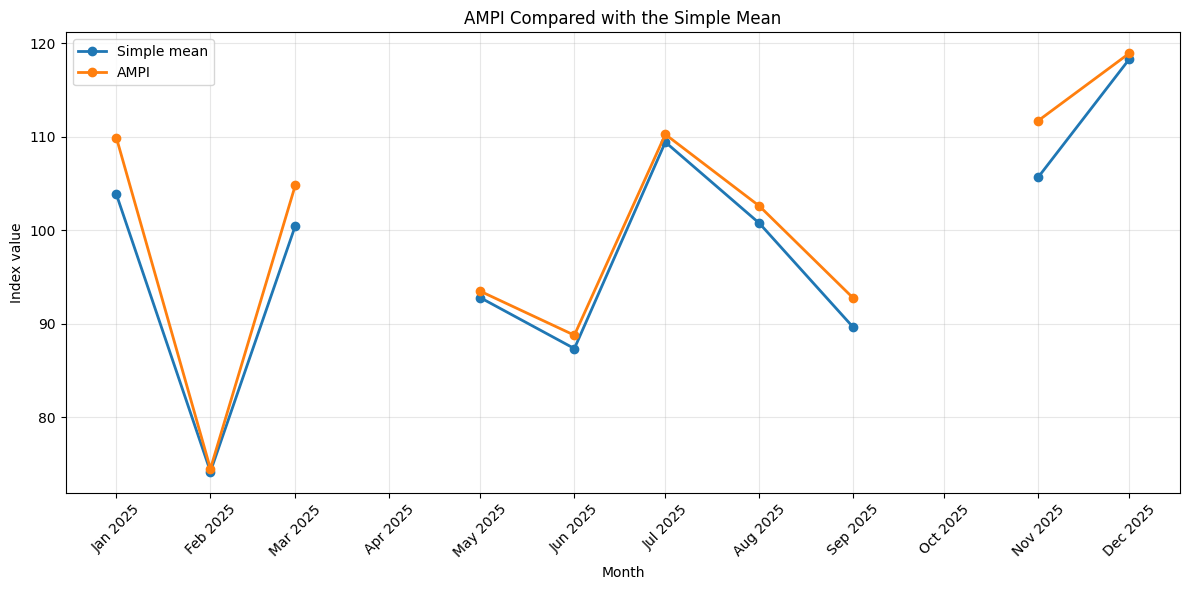


Figure saved successfully.
File: /content/figures/AMPI_vs_mean.png
Resolution: 300 DPI


In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Prepare data
comparison_plot = final_ampi_dataset.copy()
comparison_plot["month"] = pd.to_datetime(
    comparison_plot["month"]
)

all_months = pd.date_range(
    comparison_plot["month"].min(),
    comparison_plot["month"].max(),
    freq="MS"
)

comparison_plot = (
    comparison_plot
    .set_index("month")
    .reindex(all_months)
    .rename_axis("month")
    .reset_index()
)

# Create figure
plt.figure(figsize=(12, 6))

plt.plot(
    comparison_plot["month"],
    comparison_plot["Mean"],
    marker="o",
    linewidth=2,
    label="Simple mean"
)

plt.plot(
    comparison_plot["month"],
    comparison_plot["AMPI_final"],
    marker="o",
    linewidth=2,
    label="AMPI"
)

plt.xlabel("Month")
plt.ylabel("Index value")
plt.title("AMPI Compared with the Simple Mean")

plt.xticks(
    all_months,
    [d.strftime("%b %Y") for d in all_months],
    rotation=45
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Save figure
figure3_path = os.path.join(
    figures_path,
    "AMPI_vs_mean.png"
)

plt.savefig(
    figure3_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully.")
print(f"File: {figure3_path}")
print("Resolution: 300 DPI")

In [51]:
sensitivity_plot = pd.read_csv("/content/AMPI_ISS_sensitivity.csv")

print("Columns in AMPI_ISS_sensitivity.csv:")
print(sensitivity_plot.columns.tolist())

print("\nFirst 5 rows:")
display(sensitivity_plot.head())

Columns in AMPI_ISS_sensitivity.csv:
['month', 'iss_mean_z', 'iss_max_z', 'AMPI_final', 'AMPI_max', 'AMPI_difference']

First 5 rows:


,month,iss_mean_z,iss_max_z,AMPI_final,AMPI_max,AMPI_difference
0,2025-01-01,1.047448,2.130233,109.909237,109.909237,0.000000
1,2025-02-01,-0.389508,0.251259,74.503086,74.510047,0.006960
2,2025-03-01,-0.071464,1.733733,104.851484,114.485170,9.633686
3,2025-05-01,-0.098180,1.909572,93.494453,107.590061,14.095608
4,2025-06-01,-0.394562,0.804030,88.794320,93.246252,4.451931


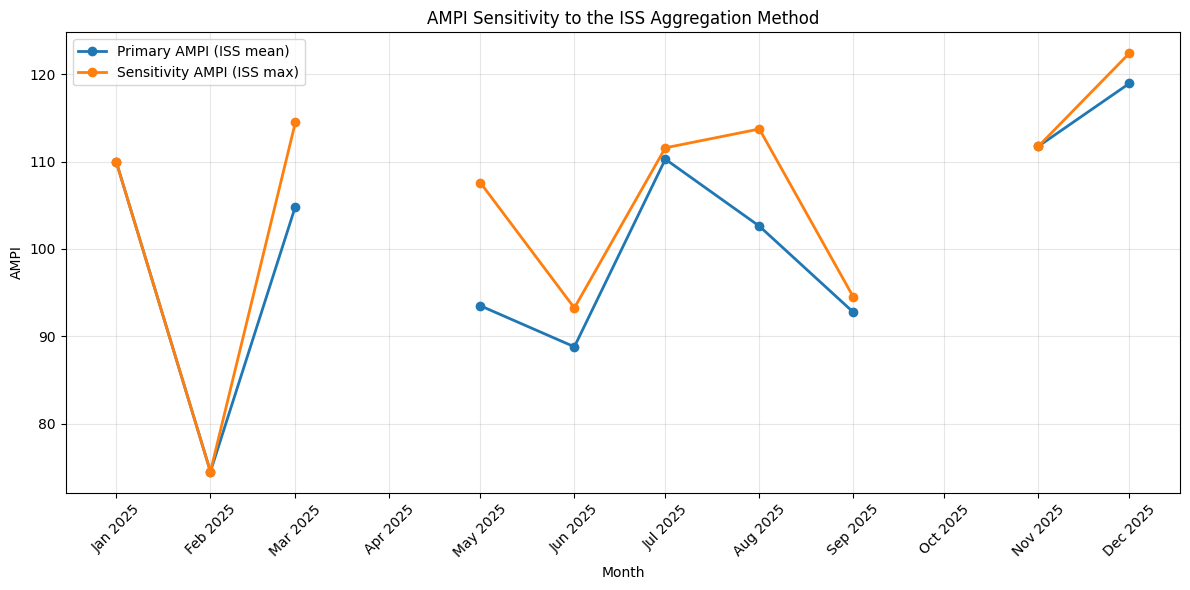


Figure saved successfully.
File: /content/figures/AMPI_ISS_sensitivity.png
Resolution: 300 DPI


In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import os

sensitivity_plot = pd.read_csv("/content/AMPI_ISS_sensitivity.csv")
sensitivity_plot["month"] = pd.to_datetime(sensitivity_plot["month"])

all_months = pd.date_range(
    sensitivity_plot["month"].min(),
    sensitivity_plot["month"].max(),
    freq="MS"
)

sensitivity_plot = (
    sensitivity_plot
    .set_index("month")
    .reindex(all_months)
    .rename_axis("month")
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    sensitivity_plot["month"],
    sensitivity_plot["AMPI_final"],
    marker="o",
    linewidth=2,
    label="Primary AMPI (ISS mean)"
)

plt.plot(
    sensitivity_plot["month"],
    sensitivity_plot["AMPI_max"],
    marker="o",
    linewidth=2,
    label="Sensitivity AMPI (ISS max)"
)

plt.xlabel("Month")
plt.ylabel("AMPI")
plt.title("AMPI Sensitivity to the ISS Aggregation Method")

plt.xticks(
    all_months,
    [d.strftime("%b %Y") for d in all_months],
    rotation=45
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

figure4_path = os.path.join(
    figures_path,
    "AMPI_ISS_sensitivity.png"
)

plt.savefig(
    figure4_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully.")
print(f"File: {figure4_path}")
print("Resolution: 300 DPI")

In [53]:
import os
import pandas as pd

print("========== AMPI FINAL VERIFICATION ==========\n")

# Required CSV files
csv_files = [
    "/content/AMPI_final_verified.csv",
    "/content/AMPI_ISS_sensitivity.csv",
    "/content/AMPI_capacity_sensitivity.csv"
]

print("CSV FILES:")
for file in csv_files:
    if os.path.exists(file):
        df = pd.read_csv(file)
        print(f"✓ {os.path.basename(file)}")
        print(f"  Rows: {len(df)} | Columns: {len(df.columns)} | Missing: {df.isna().sum().sum()}")
    else:
        print(f"✗ MISSING: {os.path.basename(file)}")

# Required figures
figure_files = [
    "/content/figures/AMPI_trend.png",
    "/content/figures/AMPI_components.png",
    "/content/figures/AMPI_vs_mean.png",
    "/content/figures/AMPI_ISS_sensitivity.png"
]

print("\nFIGURES:")
for file in figure_files:
    if os.path.exists(file):
        size_kb = os.path.getsize(file) / 1024
        print(f"✓ {os.path.basename(file)} — {size_kb:.1f} KB")
    else:
        print(f"✗ MISSING: {os.path.basename(file)}")

# Final AMPI statistics
final_df = pd.read_csv("/content/AMPI_final_verified.csv")

print("\nFINAL AMPI STATISTICS:")
print(f"Coverage: {final_df['month'].min()} to {final_df['month'].max()}")
print(f"Observations: {len(final_df)}")
print(f"AMPI minimum: {final_df['AMPI_final'].min():.4f}")
print(f"AMPI maximum: {final_df['AMPI_final'].max():.4f}")
print(f"AMPI mean: {final_df['AMPI_final'].mean():.4f}")
print(f"AMPI median: {final_df['AMPI_final'].median():.4f}")

print("\n==============================================")
print("Verification complete.")

========== AMPI FINAL VERIFICATION ==========

CSV FILES:
✓ AMPI_final_verified.csv
  Rows: 10 | Columns: 13 | Missing: 0
✓ AMPI_ISS_sensitivity.csv
  Rows: 10 | Columns: 6 | Missing: 0
✓ AMPI_capacity_sensitivity.csv
  Rows: 10 | Columns: 9 | Missing: 0

FIGURES:
✓ AMPI_trend.png — 242.9 KB
✓ AMPI_components.png — 384.4 KB
✓ AMPI_vs_mean.png — 296.0 KB
✓ AMPI_ISS_sensitivity.png — 301.0 KB

FINAL AMPI STATISTICS:
Coverage: 2025-01-01 to 2025-12-01
Observations: 10
AMPI minimum: 74.5031
AMPI maximum: 118.9541
AMPI mean: 100.7897
AMPI median: 103.7305

Verification complete.


In [54]:
# AMPI methodology verification

methodology_check = pd.DataFrame({
    "AMPI Component": [
        "Demand stress",
        "Supply stress",
        "Capacity utilization"
    ],
    "Primary Signal": [
        "sarima_resid_z",
        "iss_mean_z",
        "rho_peak_baseline"
    ],
    "Source": [
        "SARIMA residuals",
        "ISS monthly results",
        "M/M/1 queuing results"
    ],
    "Normalization": [
        "Goalpost: 70–130",
        "Goalpost: 70–130",
        "Goalpost: 70–130"
    ],
    "Role": [
        "Demand-side anomaly",
        "Broad supply-side stress",
        "Primary capacity utilization"
    ]
})

display(methodology_check)

print("\nAMPI methodology verification complete.")
print("Primary signals match the specified AMPI architecture.")

,AMPI Component,Primary Signal,Source,Normalization,Role
0,Demand stress,sarima_resid_z,SARIMA residuals,Goalpost: 70–130,Demand-side anomaly
1,Supply stress,iss_mean_z,ISS monthly results,Goalpost: 70–130,Broad supply-side stress
2,Capacity utilization,rho_peak_baseline,M/M/1 queuing results,Goalpost: 70–130,Primary capacity utilization



AMPI methodology verification complete.
Primary signals match the specified AMPI architecture.


In [55]:
# AMPI methodology: corrections and verification record

correction_record = pd.DataFrame({
    "Issue identified": [
        "Time-indexing bug in local-trend regression",
        "Standard-deviation convention mismatch"
    ],
    "Correction applied": [
        "Corrected the time index used in the local-trend regression and re-ran the validation.",
        "Aligned the standard-deviation calculation with the intended convention and re-ran the affected calculations."
    ],
    "Status": [
        "Corrected and verified",
        "Corrected and verified"
    ],
    "Methodology note": [
        "The corrected implementation was independently re-run before using the capacity validation results.",
        "The corrected convention was applied consistently in the final AMPI calculations."
    ]
})

display(correction_record)

print("\nCorrection record added successfully.")
print("Both identified calculation issues were corrected and verified.")

,Issue identified,Correction applied,Status,Methodology note
0,Time-indexing bug in local-trend regression,Corrected the time index used in the local-tre...,Corrected and verified,The corrected implementation was independently...
1,Standard-deviation convention mismatch,Aligned the standard-deviation calculation wit...,Corrected and verified,The corrected convention was applied consisten...



Correction record added successfully.
Both identified calculation issues were corrected and verified.


In [56]:
# Final numerical integrity check

final_df = pd.read_csv("/content/AMPI_final_verified.csv")

# Sort by AMPI
ranking = (
    final_df[["month", "AMPI_final"]]
    .sort_values("AMPI_final", ascending=False)
    .reset_index(drop=True)
)

ranking["Rank"] = ranking.index + 1
ranking["month"] = pd.to_datetime(ranking["month"]).dt.strftime("%b %Y")

ranking = ranking[["Rank", "month", "AMPI_final"]]

print("========== FINAL AMPI RANKING ==========\n")
display(ranking)

print("\n========== NUMERICAL CHECK ==========")
print(f"Observations : {len(final_df)}")
print(f"Minimum      : {final_df['AMPI_final'].min():.4f}")
print(f"Maximum      : {final_df['AMPI_final'].max():.4f}")
print(f"Mean         : {final_df['AMPI_final'].mean():.4f}")
print(f"Median       : {final_df['AMPI_final'].median():.4f}")
print(f"Range        : {final_df['AMPI_final'].min():.4f} – {final_df['AMPI_final'].max():.4f}")
print(f"Missing AMPI : {final_df['AMPI_final'].isna().sum()}")

# Assertions
assert len(final_df) == 10
assert final_df["AMPI_final"].isna().sum() == 0
assert round(final_df["AMPI_final"].min(), 4) == 74.5031
assert round(final_df["AMPI_final"].max(), 4) == 118.9541

print("\n✓ All numerical integrity checks passed.")

========== FINAL AMPI RANKING ==========



,Rank,month,AMPI_final
0,1,Dec 2025,118.954081
1,2,Nov 2025,111.753633
2,3,Jul 2025,110.277541
3,4,Jan 2025,109.909237
4,5,Mar 2025,104.851484
5,6,Aug 2025,102.609422
6,7,May 2025,93.494453
7,8,Sep 2025,92.749251
8,9,Jun 2025,88.794320
9,10,Feb 2025,74.503086



========== NUMERICAL CHECK ==========
Observations : 10
Minimum      : 74.5031
Maximum      : 118.9541
Mean         : 100.7897
Median       : 103.7305
Range        : 74.5031 – 118.9541
Missing AMPI : 0

✓ All numerical integrity checks passed.


In [57]:
import os

print("========== FILES READY FOR GITHUB ==========\n")

files_to_upload = [
    "/content/AMPI_final_verified.csv",
    "/content/AMPI_ISS_sensitivity.csv",
    "/content/AMPI_capacity_sensitivity.csv",
    "/content/figures/AMPI_trend.png",
    "/content/figures/AMPI_components.png",
    "/content/figures/AMPI_vs_mean.png",
    "/content/figures/AMPI_ISS_sensitivity.png"
]

for path in files_to_upload:
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"✓ {path}")
        print(f"  Size: {size_kb:.1f} KB")
    else:
        print(f"✗ MISSING: {path}")

print("\n========== CHECK COMPLETE ==========")

========== FILES READY FOR GITHUB ==========

✓ /content/AMPI_final_verified.csv
  Size: 2.4 KB
✓ /content/AMPI_ISS_sensitivity.csv
  Size: 1.1 KB
✓ /content/AMPI_capacity_sensitivity.csv
  Size: 1.7 KB
✓ /content/figures/AMPI_trend.png
  Size: 242.9 KB
✓ /content/figures/AMPI_components.png
  Size: 384.4 KB
✓ /content/figures/AMPI_vs_mean.png
  Size: 296.0 KB
✓ /content/figures/AMPI_ISS_sensitivity.png
  Size: 301.0 KB

========== CHECK COMPLETE ==========
